# Calcium Permeable AMPARs: Determining the Ratio and Current from Simulations and Experimental Data #

The relative ratio of CI/CP AMPARs is unknown for the synapses of spiral ganglion neurons attached to inner hair cells in the cochlea. By simulating different sets of CI/CP AMPAR ratios, we can use non-stationary fluctuation analysis to check how accurate our methods are against the known values. 

Once this is complete, we can look at experimental EPSC data from real cells to determine the single channel current and ratio for CP AMPARs.


## Creating the simulation files ##

The following code was used to generate the 10 simulation files in the CI_CP_redo folder in Pycharm and does not necessarily need to be run again unless changes are needed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
import math
from tqdm import tqdm
from glob import glob
import os
import re
from scipy.stats import ks_2samp


In [17]:

def JGT(t,agonist_conc): #scale in mM
    """
    Returns glutamate concentration (in M) at time t [seconds].
    """

    idx = np.abs(t_eval-t).argmin()
    if idx < 5:
        return 0
    t_corrected = (idx-5) * 0.00001 if idx < 34 else 0
    conc_1 = (1 - math.exp(-0.00001 / 0.000000002)) * math.exp(-0.00001 /  0.00002)
    # Bi-exponential function
    conc = (1 - math.exp(-t_corrected / 0.000000002)) * math.exp(-t_corrected /  0.00002)

    # Scale to ~1 mM peak (in M)
    conc = conc * (agonist_conc/conc_1)


    return conc



def agonist_conc_t(t):
    type = params['transient_type']
    if type == 'JGT':
        return JGT(t,agonist_conc)
    if type == 'Veruki':
        
        if (pulse_start <= t <= pulse_end):
            return agonist_conc
        else:
            return 0.0
    else:
        print("WARNING! Invalid agonist type")






def next_pulse_boundary_after(t):
    boundaries = []
    if t < pulse_start:
        boundaries.append(pulse_start)
    if t < pulse_end:
        boundaries.append(pulse_end)
    return min(boundaries) if boundaries else np.inf

def simulate_one_channel(t_max,agonist_conc):
    t = 0.0
    state = 0
    times = [t]
    states = [state]
    while t < t_max:
        rates = RATES[state](t)
        dests = DESTS[state]
        a0 = rates.sum()
        # boundary = next_pulse_boundary_after(t)
        if a0 <= 0:
            # t = min(boundary, t_max)
            t += .00001
            times.append(t)
            states.append(state)
            if t >= t_max:
                break
            continue
        dt = -np.log(np.random.rand()) / a0
        # if t + dt > min(boundary, t_max):
        #     t = min(boundary, t_max)
        #     times.append(t)
        #     states.append(state)
        #     continue
        t = t + dt
        r = np.random.rand() * a0
        cum = 0.0
        for i, rate in enumerate(rates):
            cum += rate
            if r <= cum:
                state = dests[i]
                break

        times.append(t)
        states.append(state)
    if times[-1] < t_max:
        times.append(t_max)
        states.append(states[-1])
    return np.array(times), np.array(states)


def events_to_sampled_open(times, states, t_eval):
    sampled = np.zeros_like(t_eval, dtype=int)
    idx = 0
    for i, tt in enumerate(t_eval):
        while idx + 1 < len(times) and times[idx + 1] <= tt:  #Converts the dt to the sample rate we want
            idx += 1
        sampled[i] = 1 if states[idx] == 6 else 0 #6 == O here
    return sampled





# # Simulate EPSCs
# RATES = {
#     0: lambda t: np.array([kC0C1 * agonist_conc_t(t,agonist_conc)]),
#     1: lambda t: np.array([kC1C0, kC1C3, kC1C2 * agonist_conc_t(t,agonist_conc)]),
#     2: lambda t: np.array([kC2C1, kC2C4, kC2O]),
#     3: lambda t: np.array([kC3C1, kC3C4 * agonist_conc_t(t,agonist_conc)]),
#     4: lambda t: np.array([kC4C2, kC4C5, kC4C3]),
#     5: lambda t: np.array([kC5O, kC5C4]),
#     6: lambda t: np.array([kOC2, kOC5])
# }
# DESTS = {
#     0: np.array([1]),           # C0 → C1
#     1: np.array([0, 3, 2]),     # C1 → C0, C3, C2
#     2: np.array([1, 4, 6]),     # C2 → C1, C4, O
#     3: np.array([1, 4]),        # C3 → C1, C4
#     4: np.array([2, 5, 3]),     # C4 → C2, C5, C3
#     5: np.array([6, 4]),        # C5 → O, C4
#     6: np.array([2, 5])         # O → C2, C5
# }



# ratio_list = [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1]
# for ci_ratio in ratio_list:
#     params['ci_ratio'] = ci_ratio
#     all_traces = []
#     np.random.seed(189)
#     if params['channel_distribution'] == 'normal':
#         mean = params['channel_mean']
#         std = params['channel_std']
#         lower_lim = params['channels_lower_lim']
#         N_array = np.random.normal(mean, std, num_traces)
#         N_array = np.clip(N_array, lower_lim, 4000)



#     elif params['channel_distribution'] == 'fixed':
#         fixed_N = params['fixed_n_value']
#         N_array =  np.full(num_traces, fixed_N)


#     if params['glu_distribution'] == 'normal':
#         mean = params['glu_mean']
#         std = params['glu_std']
#         glu_array = np.random.normal(2.5,1,num_traces)

#     elif params['glu_distribution'] == 'fixed':
#         fixed_glu = params['fixed_glu_conc']
#         glu_array = np.full(num_traces,fixed_glu)

#     ci_threshold = num_traces * params['ci_ratio'] #at this threshold we switch to the CP amplitude
#     ci_multiple = int(params['ci_ratio']  *10)
#     for trace_id in tqdm(range(num_traces), desc="Processing traces"):
#         open_counts = np.zeros_like(t_eval, dtype=int)

#         # simulate N independent channels and sum their openings
#         N = int(N_array[trace_id])
#         agonist_conc = glu_array[trace_id] * 1e-3

#         for n in range(N):
#             times_n, states_n = simulate_one_channel(t_max,agonist_conc)
#             open_counts += events_to_sampled_open(times_n, states_n, t_eval)

#         # convert to current
#         if trace_id <= ci_threshold:

#             I_pA = open_counts * params['ci_current']#g * (V_hold - V_rev)  # Amps
#         else:
#             I_pA = open_counts * params['cp_current']#g * (V_hold - V_rev)  # Amps


#         #I_pA = I * 1e12                         # picoAmps

#         all_traces.append(I_pA)

#     # Convert to DataFrame: each column is one trace, rows are timepoints
#     df = pd.DataFrame(np.array(all_traces).T, index=t_eval)

#     # plt.xlabel("Time (ms)")
#     # plt.ylabel("Current (pA)")
#     # for col in df.columns:
#     #     plt.plot(df.index*1e3,df[col],alpha=.3)
#     # template = np.mean(df,axis=1)
#     # plt.plot(df.index*1e3,template)
#     # plt.title("GluGei99")
#     # plt.show()
#     df.columns = [f"trace_{i+1}" for i in range(num_traces)]


#     df = df*-1
#     type = params['transient_type'][0:3]
#     mult = str(params['RC_multiplier'])
#     dist = params['channel_distribution'][0]
#     glu_dist = params['glu_distribution'][0]
#     df.to_excel(f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/normalglu_normaln_ci{ci_multiple}_test.xlsx")

## Calculate Expected Single-Channel Current at Each Ratio ##

## Run NSFA on Each File & Compare Results ## 

Both fCP and iT should be compared to ground-truth

In [3]:
from Scripts.EPSC_Simulation.EPSC_Simulation import EPSC_Calc, Agonist_Pulse
from Scripts.NSFA_Tools.EPSC_Matrix_Generator import matrix_generator


In [ ]:
folder_path = f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/"

excel_files = glob(os.path.join(folder_path, "*.xls*"))
df_list = []

for file_path in excel_files:
    print(f"Analyzing {file_path}")
    
    folder_path = 'EPSCs_Test_Files'

    match = re.search(r'ci(\d+)', file_path,re.IGNORECASE)

    if match:
        ci_ratio = int(match.group(1))
    else:
        ci_ratio = None
        

    params = {
        "direct_df_input": None,
        "alignment": ["None"],
        "analysis_start_point": ["peak_start"],
        "scaling": ["raw","peak_to_peak_scaling","minimize_error"],
        "output": ["linear", "parabolic"],
        "file_name": file_path,
        "folder_name": folder_path,
        "recording_duration":10,
        "mean_channels": 2200,
        "theoretical_current":1.275

    }
    
    matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=True)
    matrix_df = pd.DataFrame(matrix)
    matrix_df["CI Ratio"] = ci_ratio
    df_list.append(matrix_df)

combined_df = pd.concat(df_list,ignore_index = True) 
combined_df.to_excel(f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/combined_ratios.xlsx")











In [75]:
ratio_list = [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1]
iCI = .51
iCP = 1.53

iT_exp_list = [.51]
B_exp_list = [0]
for fCP in ratio_list[1:]: 
    B = iCP/((iCI/fCP)+(iCP-iCI))
    iT_exp = (iCI * (1-B))+(B*iCP)
    iT_exp_list.append(iT_exp) 
    B_exp_list.append(B)
cp_ratio_list = [x*100 for x in ratio_list]

ratio_df = pd.DataFrame()
ratio_df["Expected iT"] = iT_exp_list
ratio_df["Percent CP"] = cp_ratio_list 
ratio_df["Percent CI"] = [100-x for x in cp_ratio_list]
ratio_df["Expected B"] = B_exp_list
print(ratio_df)



    Expected iT  Percent CP  Percent CI  Expected B
0      0.510000         0.0       100.0    0.000000
1      0.765000        10.0        90.0    0.250000
2      0.947143        20.0        80.0    0.428571
3      1.083750        30.0        70.0    0.562500
4      1.190000        40.0        60.0    0.666667
5      1.275000        50.0        50.0    0.750000
6      1.344545        60.0        40.0    0.818182
7      1.402500        70.0        30.0    0.875000
8      1.451538        80.0        20.0    0.923077
9      1.493571        90.0        10.0    0.964286
10     1.530000       100.0         0.0    1.000000


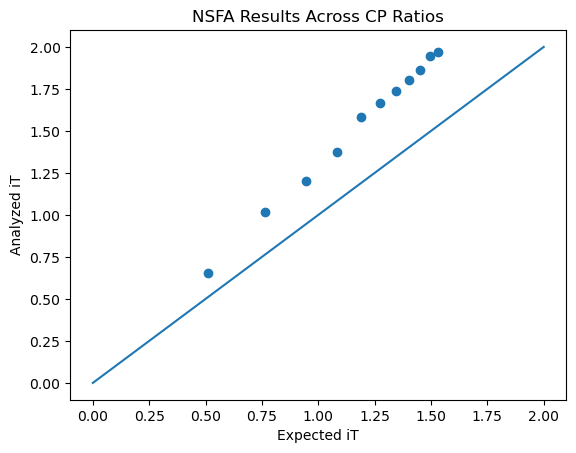

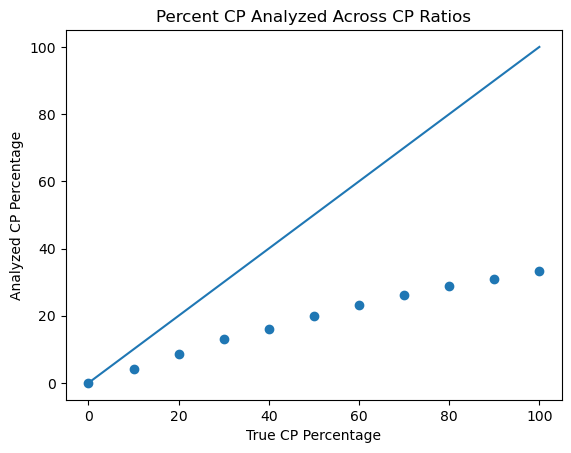

    Expected iT  Percent CP  Percent CI  Expected B  Mean Current Peak  \
0      0.510000         0.0       100.0    0.000000         351.432798   
1      0.765000        10.0        90.0    0.250000         417.193757   
2      0.947143        20.0        80.0    0.428571         485.736534   
3      1.083750        30.0        70.0    0.562500         559.612658   
4      1.190000        40.0        60.0    0.666667         633.212638   
5      1.275000        50.0        50.0    0.750000         706.377513   
6      1.344545        60.0        40.0    0.818182         775.406344   
7      1.402500        70.0        30.0    0.875000         847.254696   
8      1.451538        80.0        20.0    0.923077         917.158832   
9      1.493571        90.0        10.0    0.964286         985.845285   
10     1.530000       100.0         0.0    1.000000        1053.991679   

    Analyzed iT  Analyzed B  Analyzed iCP  Analyzed fCP  Analyzed iT_calc  
0      0.655951    0.000000      1.

In [76]:
## Compare results to true 
combined_df = (
    combined_df
    .sort_values(by="CI Ratio", ascending=False)
    .reset_index(drop=True)
)

min_error_results = combined_df[combined_df["scaling"] == "minimize_error"]

min_error_results = (
    min_error_results
    .reset_index(drop=True)
)


ratio_df["Mean Current Peak"] = min_error_results["template_max"]
ratio_df["Analyzed iT"] = min_error_results["linear_i"].values
x = np.linspace(0,2,10)
y = np.linspace(0,2,10)
plt.scatter(ratio_df["Expected iT"],ratio_df["Analyzed iT"])
plt.xlabel("Expected iT")
plt.ylabel("Analyzed iT")
plt.title("NSFA Results Across CP Ratios")
plt.plot(x,y)
plt.show()


##Now calculating the resulting fCP value
mcI = ratio_df["Mean Current Peak"][0] #The mean current for the calcium impermeable only 
iCI = ratio_df["Analyzed iT"][0]
B_list = [0]
iCP_list = [1.53]
fCP_list = [0]
iT_calc_list = [.51]
for idx, iT in enumerate(ratio_df["Analyzed iT"][1:]):
    mcT = ratio_df["Mean Current Peak"][idx+1]
    B = (mcT - mcI)/mcT
    iCP = iCI  + ( (iT - iCI) / B)
    fCP = iCI/( (iCP/B) - (iCP-iCI) )
    iT_calc = ((1-B)*iCI)+(B*iCP)
    B_list.append(B)
    B = iCP/((iCI/fCP)+(iCP-iCI))

    iCP_list.append(iCP)
    fCP_list.append(fCP)
    iT_calc_list.append(iT_calc)

ratio_df["Analyzed B"] = B_list
ratio_df["Analyzed iCP"] = iCP_list
ratio_df["Analyzed fCP"] = fCP_list
ratio_df["Analyzed iT_calc"] = iT_calc_list


x = np.linspace(0,100,10)
y = np.linspace(0,100,10)
plt.scatter(ratio_df["Percent CP"] ,ratio_df["Analyzed fCP"] * 100)
plt.xlabel("True CP Percentage")
plt.ylabel("Analyzed CP Percentage")
plt.title("Percent CP Analyzed Across CP Ratios")
plt.plot(x,y)
plt.show()



print(ratio_df)


## Bin & Filter Each File ##

We are binning by equal rise times in .02 intervals and selecting for the bins which have >100 traces (minimum shown to be necessary)

In [4]:
def rise_times_histogram_creator(df,folder_name,plt_show = False,sampling_rate = .02,export_name="risetimes",subtract_base = False):
    max_amplitudes = df.abs().max(axis=0)
    rise_times = []
    for col in df.columns:
        trace = df[col].abs()

        # if subtract_base:
        #     baseline  = np.mean(df[col][0:15]) #mean of the first .3ms, .02ms/sample means 15samples = .3ms
        #     trace = trace - baseline

        max_amp = trace.max()
        threshold_20 = 0.2 * max_amp
        threshold_80 = 0.8 * max_amp

        # Find where the signal first crosses the 10% threshold
        above_20 = trace >= threshold_20
        above_80 = trace >= threshold_80

        try:
            idx_20 = above_20.idxmax()  # First index where >= threshold_10
            idx_80 = above_80.idxmax()

            if idx_20 == 0:
                time = idx_80 * sampling_rate
                rise_times.append(time)
                continue  # Can't interpolate at the start of trace

            # Interpolate time_20
            prev_idx_20 = idx_20 - 1
            x0, y0 = prev_idx_20, trace[prev_idx_20]
            x1, y1 = idx_20, trace[idx_20]
            time_20_interp = x0 + (threshold_20 - y0) / (y1 - y0)

            # Interpolate time_80
            prev_idx_80 = idx_80 - 1
            x0, y0 = prev_idx_80, trace[prev_idx_80]
            x1, y1 = idx_80, trace[idx_80]
            time_80_interp = x0 + (threshold_80 - y0) / (y1 - y0)

            # Convert to seconds
            rise_time = (time_80_interp - time_20_interp) * sampling_rate
            rise_times.append(rise_time)

        except Exception as e:
            print(f"Interpolation failed for column {col}: {e}")

    # print(f"Rise Time shape: {len(rise_times)}")
    # print(f"Trace shape: {df.shape}")

    rise_times_df = pd.DataFrame({
        'Trace':df.columns,
        'Rise Time (20% to 80%)': rise_times
    })
    bin_width = .02
    bins = np.arange(np.min(rise_times), np.max(rise_times) + bin_width, bin_width)

    # rise_times_df.to_excel(f'{export_name}.xlsx',index=False)
    if plt_show == True:
        plt.figure()
        plt.hist(rise_times, bins=bins, edgecolor='black')
        plt.xlabel('Rise Times (ms)')
        plt.title(f'Rise Times Histogram')
        plt.ylabel('Frequency')
        plt.show()
        plt.savefig(f'rise_times_histogram.png')
    return rise_times

##For later in the experiment, also defining the amplitude extraction
def amplitude_histogram_creator(df,folder_name,plt_show = False):
    max_amplitudes = df.abs().max(axis=0)
    max_amplitudes.to_excel('max_amplitudes.xlsx',index_label='Trace', header=['Max Amplitude'])

    if plt_show == True:
        plt.figure()
        plt.hist(max_amplitudes, bins=10, edgecolor='black')
        plt.xlabel('EPSC Amplitudes (pA)')
        plt.ylabel('Frequency')
        plt.title('EPSC Amplitude Bins')
        plt.savefig(f'{folder_name}/peak_amplitude_histograms.png', dpi=300, bbox_inches='tight')
        plt.show()
    return max_amplitudes

In [101]:

folder_path = f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/"
save_path = f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts/CI_CP_Redo/Binned_EPSCs/"
excel_files = glob(os.path.join(folder_path, "*.xls*"))
df_list = []

for file_path in excel_files:
    df = pd.read_excel(file_path, skiprows=1,sheet_name=0).iloc[:, 1:] #First row and column are just labels
    file_name  = file_path.split(r'_')[-1].split('.')[0]

    
    # Compute rise times
    print(df)
    rise_times = rise_times_histogram_creator(df, "/", sampling_rate=0.01, plt_show=True)
    print(rise_times)
    
    # Convert to Series with column names as index
    rise_times = pd.Series(rise_times, index=df.columns)
    
    # Define bin width and edges
    bin_width = 0.02
    bins = np.arange(rise_times.min(), rise_times.max() + bin_width, bin_width)
    
    # Bin the rise times
    binned = pd.cut(rise_times, bins=bins, include_lowest=True)
    
    # Extract bin categories
    bin_categories = binned.cat.categories
    print("Bin categories:", bin_categories)
    bin_counts = binned.value_counts().sort_index()  # sort_index ensures bins are in order
    
    # Plot as a bar chart
    plt.figure(figsize=(10,6))
    bin_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    
    plt.xlabel("Rise Time Bins (s)")
    plt.ylabel("Number of Traces")
    plt.title("Distribution of Rise Times by Bin")
    plt.xticks(rotation=45, ha='right')  # rotate bin labels
    plt.tight_layout()
    plt.show()
    # Create Excel file with a tab per bin
    with pd.ExcelWriter(folder_path+file_name+'_binned.xlsx', engine="openpyxl") as writer:
        for i, category in enumerate(bin_categories, start=1):
            # Get columns that fall into this bin
            cols_in_bin = rise_times.index[binned == category]
            if len(cols_in_bin) > 20:
                subset = df.loc[:, cols_in_bin]
    
    
                # Write subset to Excel
                subset.to_excel(writer, sheet_name=f"Bin_{i}", index=False, header=False)
    
    print("Excel file created...")

KeyboardInterrupt: 

## Run NSFA on Binned to Extract iT ## 

In [ ]:
#Dragged files into Binned_EPSCs folder
folder_path = 'C:\\Users\\j.mona\\Documents\\GitHub\\Python-EPSC-NSFA-Pipeline\\experimental-scripts\\CI_CP_Redo\\Binned_ESPCs'

excel_files = glob(os.path.join(folder_path, "*.xls*"))
df_list = []

for file_path in excel_files:
    
    folder_path = 'EPSCs_Test_Files'
    match = re.search(r'ci(\d+)', file_path,re.IGNORECASE)
    if match:
        ci_ratio = int(match.group(1))
        print(f"Working on ci ratio: {ci_ratio}")
        if ci_ratio == 10:
            print("TEN DETECTED")
            ten = True
        else:
            ten = False
        iT = ratio_df[ratio_df["Percent CI"] == float(ci_ratio*10)]["Expected iT"]
        iT_scalar = float(iT.iloc[0])
        print(iT_scalar)


    params = {
        "direct_df_input": None,
        "alignment": ["None"],
        "analysis_start_point": ["peak_start"],
        "scaling": ["raw","peak_to_peak_scaling","minimize_error"],
        "output": ["linear", "parabolic"],
        "file_name": file_path,
        "folder_name": folder_path,
        "recording_duration":10,
        "mean_channels": 2200,
        "theoretical_current":iT_scalar 

    }

    matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=ten)
    matrix_df = pd.DataFrame(matrix)
    matrix_df["CI Ratio"] = ci_ratio
    df_list.append(matrix_df)

all_binned_ratio_nsfa = pd.concat(df_list,ignore_index = True) 
all_binned_ratio_nsfa.to_excel(f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/all_binned_ratio_nsfa.xlsx")
    


    

## Evaluate iT ##

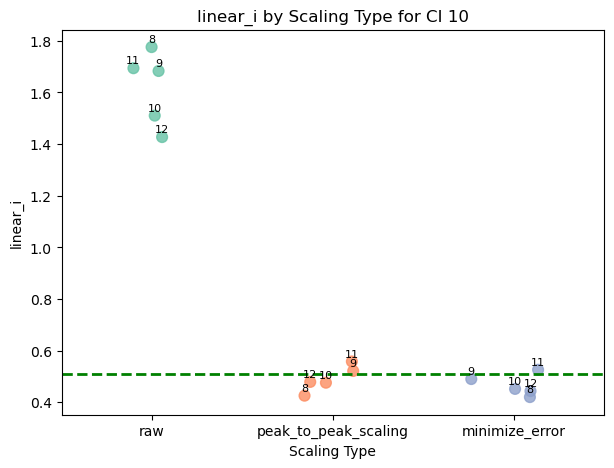

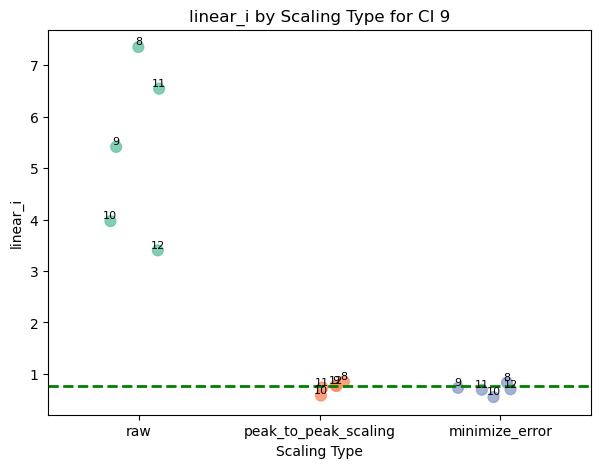

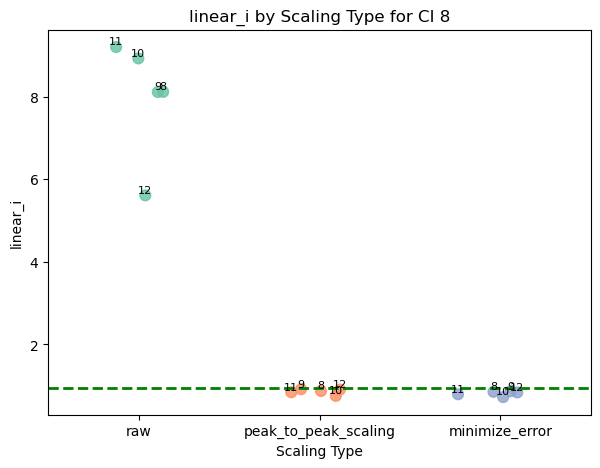

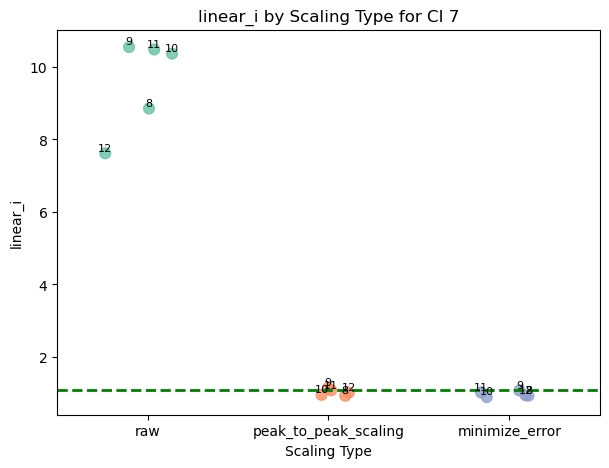

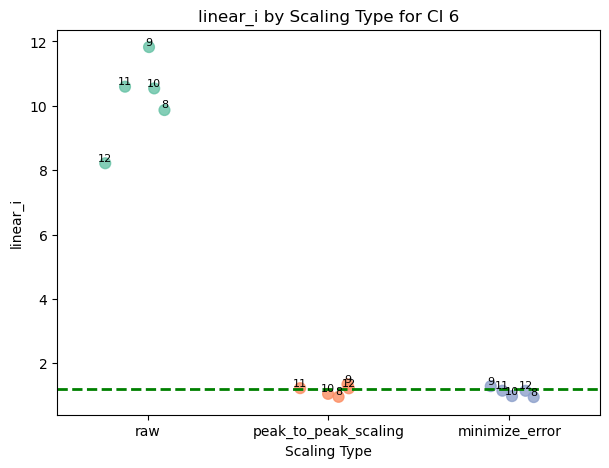

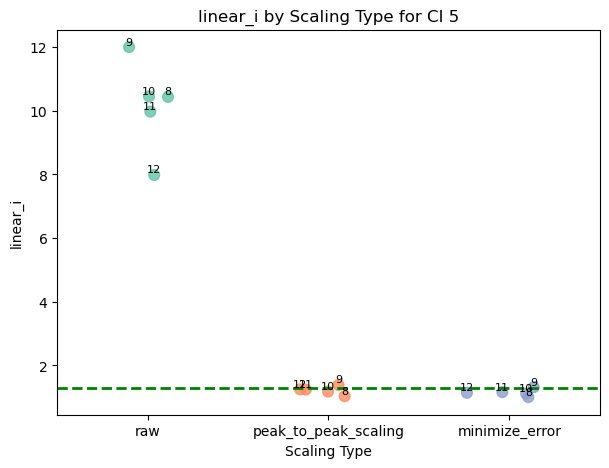

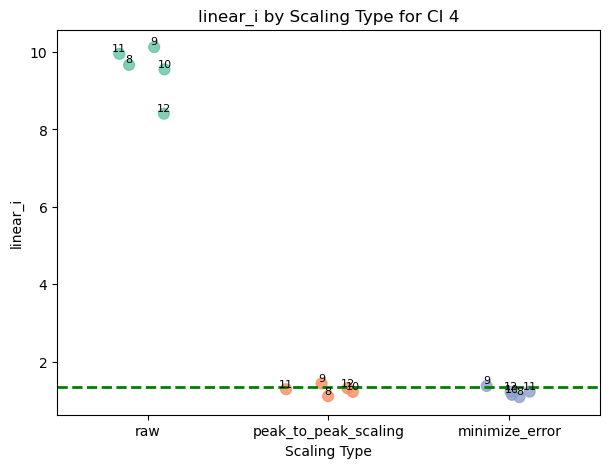

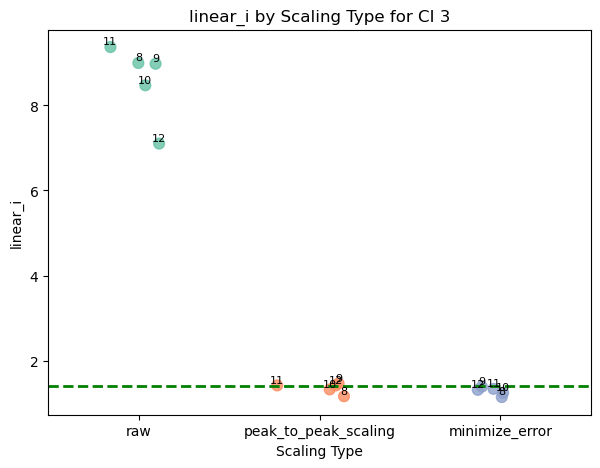

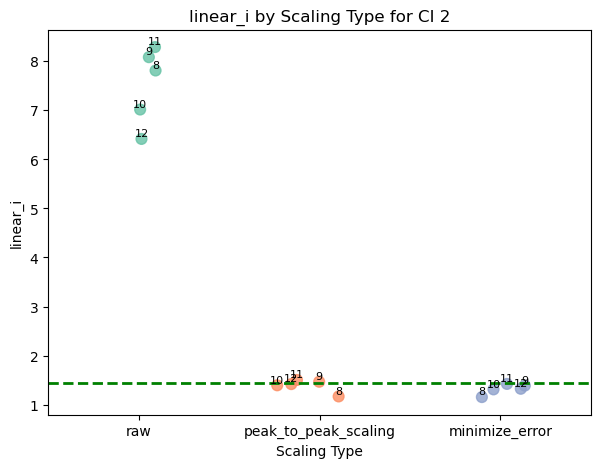

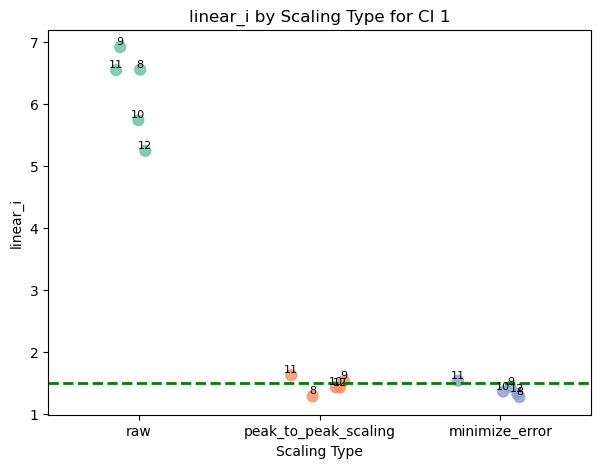

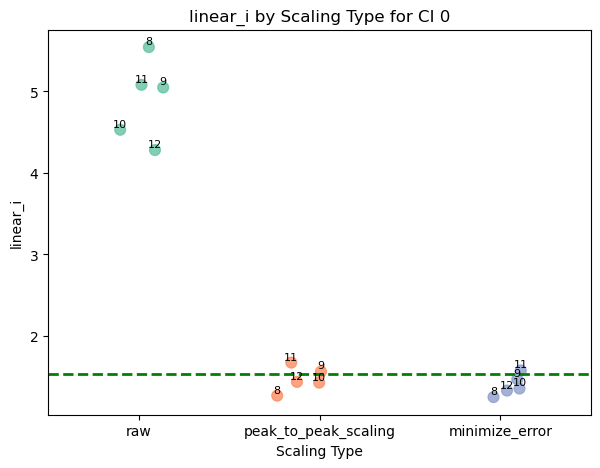

In [132]:
import seaborn as sns

all_binned_ratio_nsfa["bin"] = (
    all_binned_ratio_nsfa["cell_name"]
    .str.extract(r"Bin_(\d+)")
    .astype(int)
)

all_binned_ratio_nsfa = (
    all_binned_ratio_nsfa
    .sort_values(by="CI Ratio", ascending=False)
    .reset_index(drop=True)
)

mean_iT_list = []
binned_template_max_list = []
for ratio in all_binned_ratio_nsfa["CI Ratio"].unique():

    binned_nsfa = all_binned_ratio_nsfa[all_binned_ratio_nsfa["CI Ratio"] == ratio]
    # binned_nsfa = pd.read_excel(r"C:\Users\j.mona\Documents\GitHub\Python-EPSC-NSFA-Pipeline\Scripts\Experiments\Creating_NSFA_Debugger\testing-cell-ratio.xlsx")
    
    df = binned_nsfa.copy()
    iT = ratio_df[ratio_df["Percent CI"] == float(ratio*10)]["Expected iT"]
    iT_scalar = float(iT.iloc[0])
    
    # Make scaling a categorical with a stable order (optional)
    categories = ['raw','peak_to_peak_scaling','minimize_error']
    df['scaling'] = pd.Categorical(df['scaling'], categories=categories, ordered=True)
    
    # map categories to x positions
    x_codes = df['scaling'].cat.codes.to_numpy()
    
    # reproducible jitter
    rng = np.random.default_rng(42)
    jitter_strength = 0.12                          # adjust to spread points horizontally
    x_jitter = x_codes + rng.normal(0, jitter_strength, size=len(df))
    
    # color palette (one color per category)
    palette = sns.color_palette("Set2", n_colors=len(categories))
    colors = [palette[c] for c in x_codes]
    
    plt.figure(figsize=(7,5))
    plt.scatter(x_jitter, df['linear_i'], c=colors, s=60, alpha=0.8)
    
    # add text labels (Bin)
    for x, y, lbl in zip(x_jitter, df['linear_i'], df['bin']):   # ensure column name is 'bin'
        plt.text(x, y + 0.01, str(lbl), ha='center', va='bottom', fontsize=8)
    
    plt.axhline(y=iT_scalar, color='green', linestyle='--', linewidth=2, label='Expected Current')
    ax = plt.gca()
    ax.set_xlim(-0.5, len(categories) - 0.5)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories)
    # cosmetics
    plt.xticks(range(len(categories)), categories)
    plt.xlabel("Scaling Type")
    plt.ylabel("linear_i")
    plt.title(f"linear_i by Scaling Type for CI {ratio}")
    plt.show()

    minimize_error_only = binned_nsfa[binned_nsfa["scaling"] == "peak_to_peak_scaling"]
    
    mean_iT = np.mean(minimize_error_only["linear_i"])

    mean_iT_list.append(mean_iT)

    template_mean = minimize_error_only['template_max'].mean()

    binned_template_max_list.append(template_mean)



## Compare iT ##

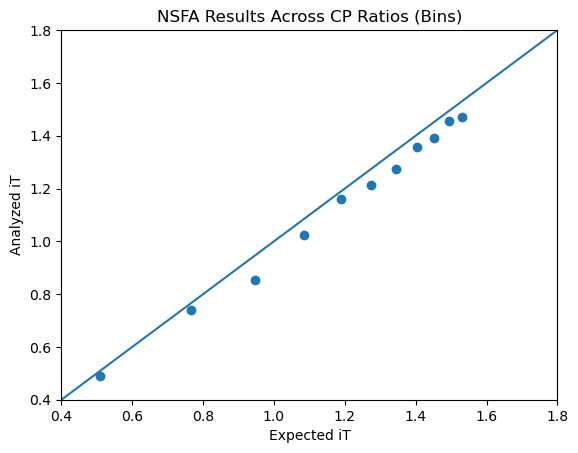

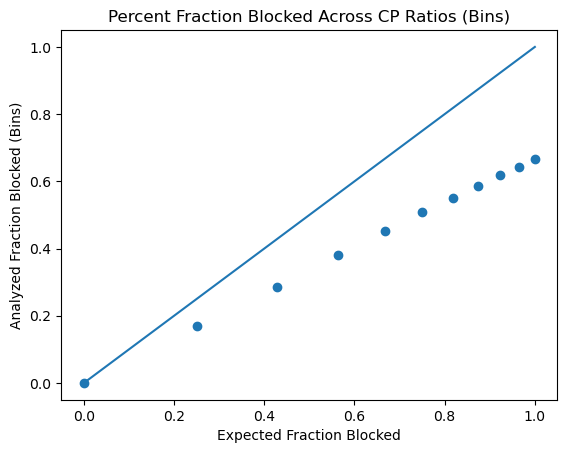

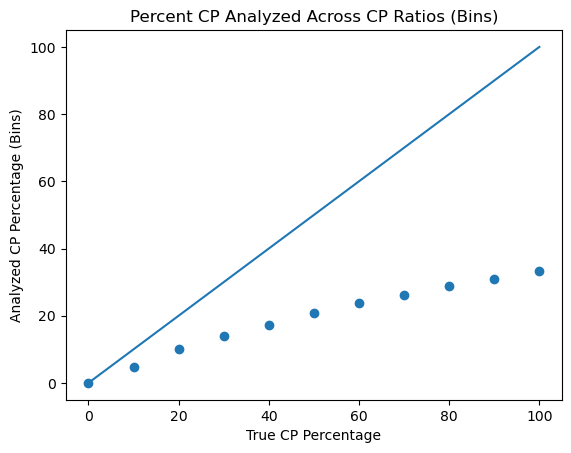

    Expected iT  Percent CP  Percent CI  Expected B  Mean Current Peak  \
0      0.510000         0.0       100.0    0.000000         351.432798   
1      0.765000        10.0        90.0    0.250000         417.193757   
2      0.947143        20.0        80.0    0.428571         485.736534   
3      1.083750        30.0        70.0    0.562500         559.612658   
4      1.190000        40.0        60.0    0.666667         633.212638   
5      1.275000        50.0        50.0    0.750000         706.377513   
6      1.344545        60.0        40.0    0.818182         775.406344   
7      1.402500        70.0        30.0    0.875000         847.254696   
8      1.451538        80.0        20.0    0.923077         917.158832   
9      1.493571        90.0        10.0    0.964286         985.845285   
10     1.530000       100.0         0.0    1.000000        1053.991679   

    Analyzed iT  Analyzed B  Analyzed iCP  Analyzed fCP  Analyzed iT_calc  \
0      0.655951    0.000000      1

In [133]:
ratio_df["Analyzed Binned iT"] = mean_iT_list

ratio_df["Mean Binned Current Peak"] = binned_template_max_list


x = np.linspace(0,2,10)
y = np.linspace(0,2,10)
plt.scatter(ratio_df["Expected iT"],ratio_df["Analyzed Binned iT"])
plt.xlabel("Expected iT")
plt.ylabel("Analyzed iT")
plt.xlim(.4, 1.8)
plt.ylim(.4, 1.8)

plt.title("NSFA Results Across CP Ratios (Bins)")
plt.plot(x,y)
plt.show()


##Now calculating the resulting fCP value
mcI = ratio_df["Mean Binned Current Peak"][0] #The mean current for the calcium impermeable only 
iCI = ratio_df["Analyzed Binned iT"][0]
B_list = [0]
iCP_list = [1.53]
fCP_list = [0]
iT_calc_list = [.51]
for idx, iT in enumerate(ratio_df["Analyzed Binned iT"][1:]):
    mcT = ratio_df["Mean Binned Current Peak"][idx+1]
    B = (mcT - mcI)/mcT
    iCP = iCI  + ( (iT - iCI) / B)
    iT_calc = ((1-B)*iCI)+(B*iCP)
    # B_list.append(B)
    # B = iCP/((iCI/fCP)+(iCP-iCI))
    fCP = iCI/( (iCP/B) - (iCP-iCI) )
    
    B_list.append(B)
    iCP_list.append(iCP)
    fCP_list.append(fCP)
    iT_calc_list.append(iT_calc)

ratio_df["Analyzed Binned B"] = B_list
ratio_df["Analyzed Binned iCP"] = iCP_list
ratio_df["Analyzed Binned fCP"] = fCP_list
ratio_df["Analyzed Binned iT_calc"] = iT_calc_list

x = np.linspace(0,1,10)
y = np.linspace(0,1,10)

plt.scatter(ratio_df["Expected B"] ,ratio_df["Analyzed Binned B"] )
plt.xlabel("Expected Fraction Blocked")
plt.ylabel("Analyzed Fraction Blocked (Bins)")
plt.title("Percent Fraction Blocked Across CP Ratios (Bins)")
plt.plot(x,y)
plt.show()

x = np.linspace(0,100,10)
y = np.linspace(0,100,10)

plt.scatter(ratio_df["Percent CP"] ,ratio_df["Analyzed Binned fCP"] * 100)
plt.xlabel("True CP Percentage")
plt.ylabel("Analyzed CP Percentage (Bins)")
plt.title("Percent CP Analyzed Across CP Ratios (Bins)")
plt.plot(x,y)
plt.show()



print(ratio_df)

## Fitting Experimental IEM data to Simulation Data ## 

In [5]:
'''
Here we will make a quick optimization algorithm to create a simulation with a channel mean and SD that best matches the rise time and 
amplitude distribution of each IEM-treated cell.

Then for the same cell, we will optimize the number of CP channels (added to a simulation created from the optimized normal distribution) that results
in the most accurate risetime/amplitude distribution match to the control condition of that cell.

The resulting dataframe will look like this: 

|CELL ID|CI Channel Mean|CI Channel SD|Optimized # CP Added|Exper IEM Template Peak|Exper Control Template Peak| SIM IEM Template Peak| SIM Control Template Peak|

'''

'\nHere we will make a quick optimization algorithm to create a simulation with a channel mean and SD that best matches the rise time and \namplitude distribution of each IEM-treated cell.\n\nThen for the same cell, we will optimize the number of CP channels (added to a simulation created from the optimized normal distribution) that results\nin the most accurate risetime/amplitude distribution match to the control condition of that cell.\n\nThe resulting dataframe will look like this: \n\n|CELL ID|CI Channel Mean|CI Channel SD|Optimized # CP Added|Exper IEM Template Peak|Exper Control Template Peak| SIM IEM Template Peak| SIM Control Template Peak|\n\n'

In [6]:
'''
Next we will want to run some calculations to get expected values for our NSFA run. 'Expected' here refers to the expectation of how our simulation
should behave, not necessarily experimental data.

The new dataframe columns will include

|CELL ID| Expected iCI | Expected iT | Expected iCP | Expected B| Expected fCP   
'''

"\nNext we will want to run some calculations to get expected values for our NSFA run. 'Expected' here refers to the expectation of how our simulation\nshould behave, not necessarily experimental data.\n\nThe new dataframe columns will include\n\n|CELL ID| Expected iCI | Expected iT | Expected iCP | Expected B| Expected fCP   \n"

## Extracting NSFA from Experimental IEM and Control Data ##

In [5]:

'''

We will want to run NSFA, then also run the binning/mean extraction, on both simulation and experimental data.

Ultimately, master dataframe columns should now include

|CELL ID| Analyzed Simulation Mean Binned iCT| Analyzed Simulation iCI | Analyzed Simulation iT | Analyzed Simulation iCP | Analyzed Simulation B| Analyzed Simulation fCP 

and

|CELL ID|IEM DOSE| Analyzed Exper Mean Binned iCT| Analyzed Exper iCI | Analyzed Exper iT | Analyzed Exper iCP | Analyzed Exper B| Analyzed Exper fCP 

'''
control_path = r'C:\Users\j.mona\Documents\GitHub\Python-EPSC-NSFA-Pipeline\data-files\Control_Experimental_EPSCs_Juan_Jan12.xlsx'
control_epscs = pd.ExcelFile(control_path) #The last 3 don't have that, removed manually
print(f"Control EPSCs: {control_epscs.sheet_names}")

IEM_path = r'C:\Users\j.mona\Documents\GitHub\Python-EPSC-NSFA-Pipeline\data-files\IEM_Data\IEM_EPSCs_Jan12.xlsx'
IEM_epscs = pd.ExcelFile(IEM_path)
print(f"IEM EPSCs: {IEM_epscs.sheet_names}")

master_df = pd.DataFrame()
master_df["CELL ID"] = control_epscs.sheet_names
IEM_dose_list = []
for cell in IEM_epscs.sheet_names:
    match = re.search(r'IEM(\d+)', cell,re.IGNORECASE)
    dose = int(match.group(1))
    IEM_dose_list.append(dose)
print(IEM_dose_list)
master_df["IEM DOSE"] = IEM_dose_list


print("\n Dataframe initialized...")
print(master_df)

sorted_master_df = (
    master_df
    .sort_values(by="IEM DOSE", ascending=True)
    .reset_index(drop=True)
)


Control EPSCs: ['JG18109A', 'JG18320A', 'JG20O21C', 'JG20O22B', 'JG21O23A', 'JG22221A', 'JG22221C', 'JG18D04A', 'JG18D04B', 'JG18D05A', 'JG17D19A']
IEM EPSCs: ['JG18109A_IEM10', 'JG18320A_IEM30', 'JG20O21C_IEM10', 'JG20O22B_IEM3', 'JG21O23A_IEM10', 'JG22221A_IEM6', 'JG22221C_IEM6', 'JG18D04A_IEM100', 'JG18D04B_IEM100', 'JG18D05A_IEM100', 'JG17D19A_IEM10']
[10, 30, 10, 3, 10, 6, 6, 100, 100, 100, 10]

 Dataframe initialized...
     CELL ID  IEM DOSE
0   JG18109A        10
1   JG18320A        30
2   JG20O21C        10
3   JG20O22B         3
4   JG21O23A        10
5   JG22221A         6
6   JG22221C         6
7   JG18D04A       100
8   JG18D04B       100
9   JG18D05A       100
10  JG17D19A        10


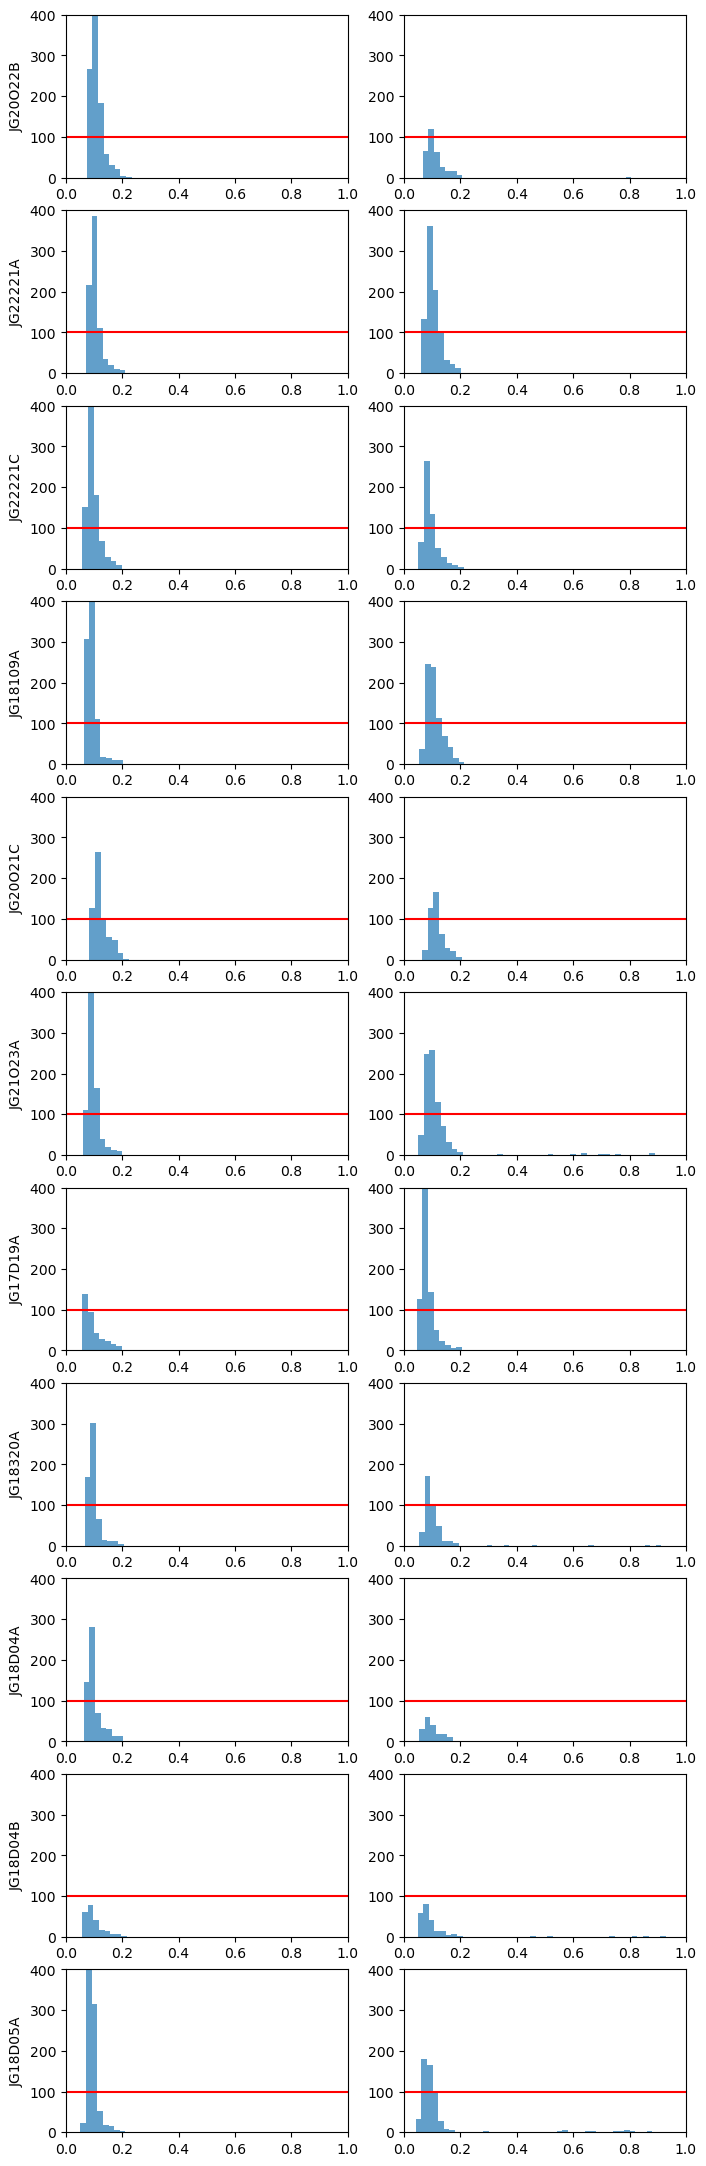

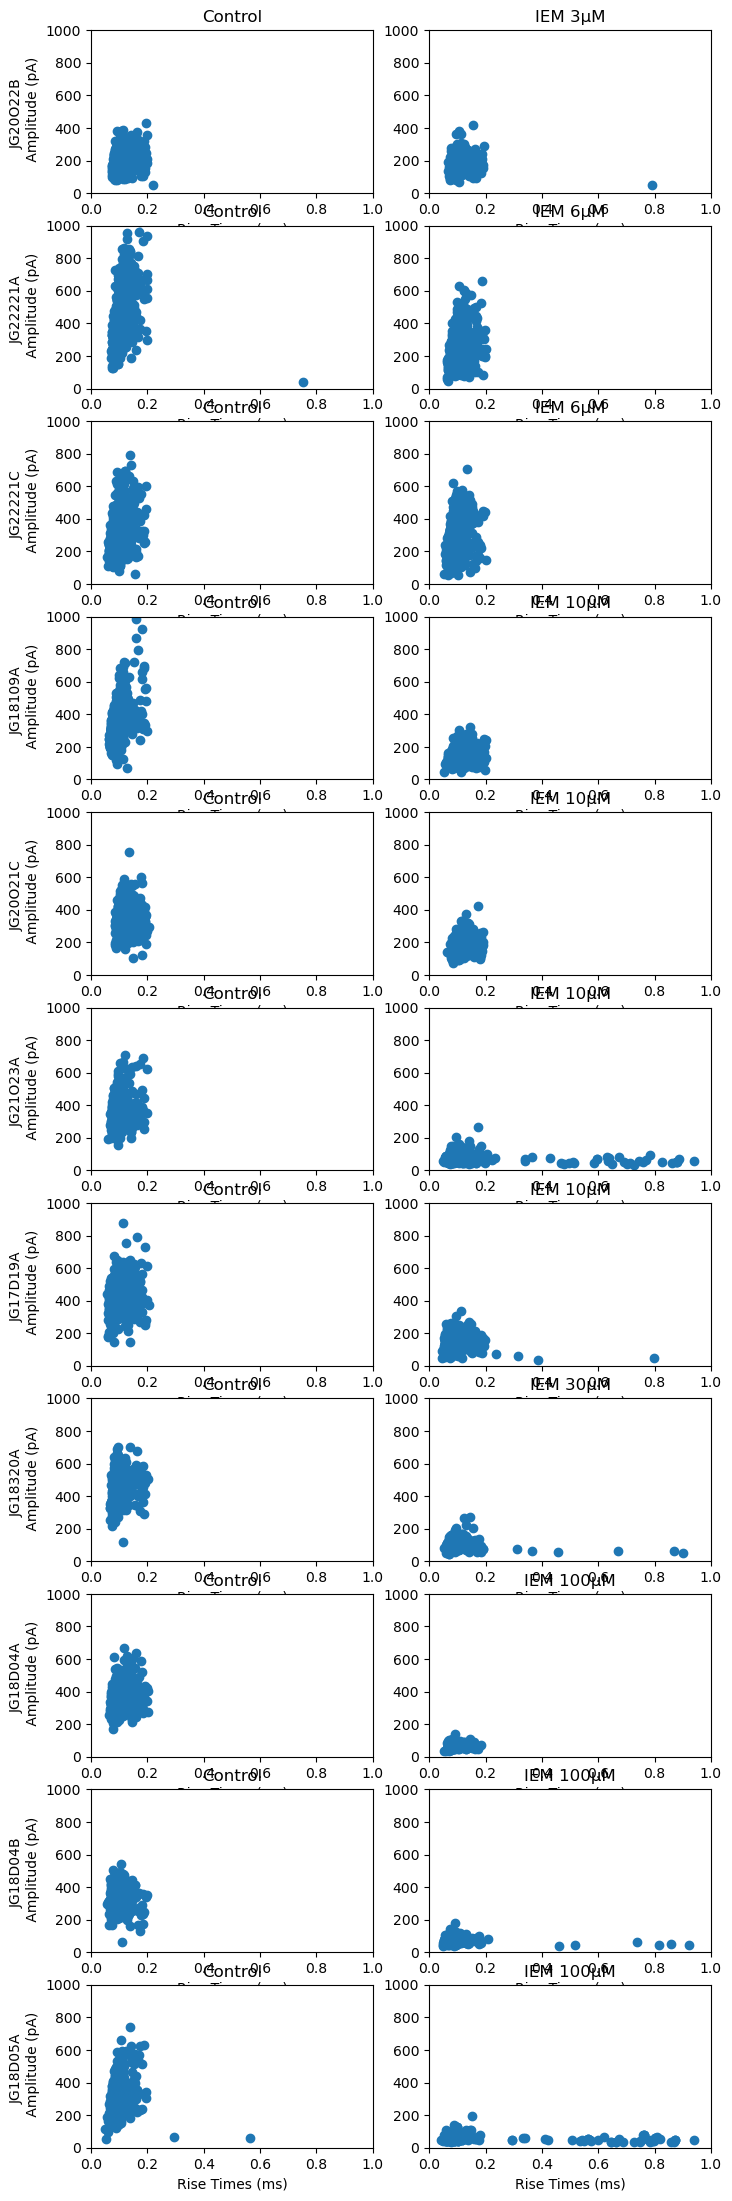

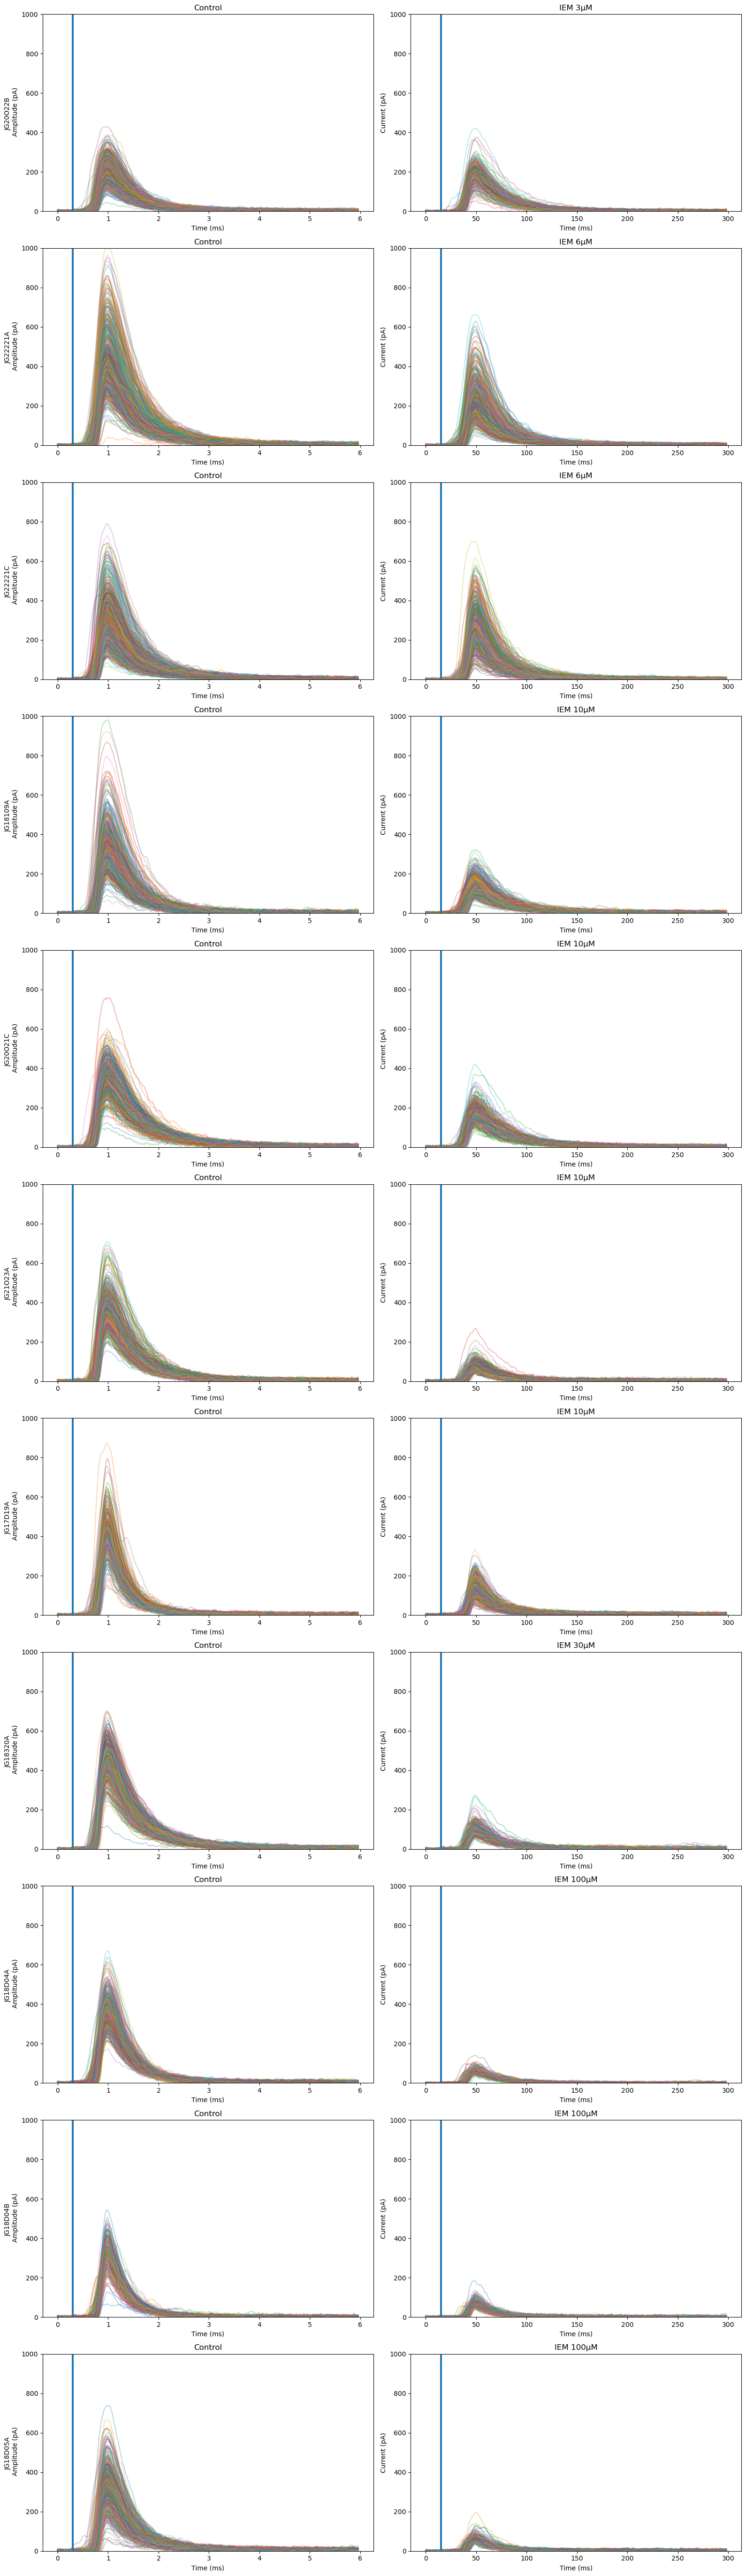

In [17]:
##Comparing rise times!

n_cells = 11

fig, axes = plt.subplots(nrows=n_cells,ncols=2, figsize=(8,2.5*n_cells))
fig2, axes2 = plt.subplots(nrows=n_cells,ncols=2,figsize=(8,2.5*n_cells))
fig3,axes3 = plt.subplots(nrows=n_cells,ncols=2,figsize=(16,5*n_cells))

for i, cell in enumerate(sorted_master_df["CELL ID"]):
    
    control_df = pd.read_excel(control_path ,sheet_name=cell)
    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)

    bin_width = .02
    # Compute rise times
    rise_times = np.array(rise_times_histogram_creator(control_df, "/", sampling_rate=0.02, plt_show=False))
    IEM_rise_times = np.array(rise_times_histogram_creator(IEM_df, "/", sampling_rate=0.02, plt_show=False))
    bins = np.arange(rise_times.min(), rise_times.max() + bin_width, bin_width)
    IEM_bins = np.arange(IEM_rise_times.min(), IEM_rise_times.max() + bin_width, bin_width)

    # plot control on left
    axes[i,0].hist(rise_times,bins=bins,alpha=.7)
    axes[i,0].axhline(y=100, color='r', linestyle='-')
    axes[i,0].set_ylabel(cell) 

    #plot IEM on right
    axes[i,1].hist(IEM_rise_times,bins=IEM_bins,alpha=.7)
    axes[i,1].axhline(y=100, color='r', linestyle='-')


    #Compute amplitudes
    amps = np.array(amplitude_histogram_creator(control_df,"/",plt_show = False))
    IEM_amps = np.array(amplitude_histogram_creator(IEM_df,"/",plt_show = False))

    axes2[i,0].scatter(rise_times,amps)
    axes2[i,0].set_ylabel(f"{cell} \n Amplitude (pA)") 
    axes2[i,0].set_xlabel("Rise Times (ms)") 

    axes2[i,0].set_title("Control")

    axes2[i,1].scatter(IEM_rise_times,IEM_amps)
    axes2[i,1].set_title(f"IEM {IEM_DOSE}μM")
    axes2[i,1].set_xlabel("Rise Times (ms)") 


    # Plot raw EPSCs
    for col in control_df.columns:
        baseline  = np.mean(control_df[col][0:15])    
        clean_col = control_df[col] - baseline
        axes3[i,0].plot((control_df.index*.02),clean_col,alpha=.3)
        axes3[i,0].axvline(x=.3)

    axes3[i,0].set_ylabel(f"{cell} \n Amplitude (pA)") 
    axes3[i,0].set_title("Control")
    axes3[i,0].set_xlabel("Time (ms)")



    for col in IEM_df.columns:
        baseline  = np.mean(IEM_df[col][0:15])   
        clean_col = IEM_df[col] - baseline
        axes3[i,1].plot((IEM_df.index),clean_col,alpha=.3) 
        axes3[i,1].axvline(x=15)

    axes3[i,1].set_ylabel("Current (pA)")
    axes3[i,1].set_title(f"IEM {IEM_DOSE}μM")
    axes3[i,1].set_xlabel("Time (ms)")



    







x_min, x_max = 0, 1     #  rise time range
y_min, y_max = 0, 400  #  count or density

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

############
x_min, x_max = 0, 1     #  rise time range
y_min, y_max = 0, 1000  #  amplitude range

for ax_row in axes2:
    for ax in ax_row:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)


##########
for ax_row in axes3:
    for ax in ax_row:
        ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig("Experimental_RiseTime_Amp_Plots.png")
plt.show()




    

In [ ]:
#Running NSFA to get the experimental results for IEM vs control
folder_path = f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/"
control_cell_i_list = []
IEM_cell_i_list = []
for cell in sorted_master_df["CELL ID"]:
    print(f"Analyzing {cell}")
    control_i_bins_list = []
    IEM_i_bins_list = []
    
    control_df = pd.read_excel(control_path ,sheet_name=cell)
    for col in control_df.columns:
                baseline = np.mean(control_df[col][0:15])
                control_df[col] = control_df[col] - baseline

    
    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
    for col in IEM_df.columns:
                baseline = np.mean(IEM_df[col][0:15])
                IEM_df[col] = IEM_df[col] - baseline


    
    # Compute rise times
    rise_times = rise_times_histogram_creator(control_df, "/", sampling_rate=0.02, plt_show=True)
    IEM_rise_times = rise_times_histogram_creator(IEM_df, "/", sampling_rate=0.02, plt_show=True)
    # Convert to Series with column names as index
    rise_times = pd.Series(rise_times, index=control_df.columns)
    IEM_rise_times = pd.Series(IEM_rise_times, index=IEM_df.columns)
    
    # Define bin width and edges
    bin_width = .02
    freq_cutoff = 100
    bins = np.arange(rise_times.min(), rise_times.max() + bin_width, bin_width)
    IEM_bins = np.arange(IEM_rise_times.min(), IEM_rise_times.max() + bin_width, bin_width)
    # Bin the rise times
    binned = pd.cut(rise_times, bins=bins, include_lowest=True)
    IEM_binned = pd.cut(IEM_rise_times, bins=IEM_bins, include_lowest=True)

    
    # Extract bin categories (CONTROL)
    bin_categories = binned.cat.categories
    bin_categories = [cat for cat in binned.cat.categories if cat.right <= 0.4]

    print(f"Control bin_categories {bin_categories}")
    bin_counts = binned.value_counts().sort_index()  # sort_index ensures bins are in order
    for i, category in enumerate(bin_categories, start=1):
        # Get columns that fall into this bin
        cols_in_bin = rise_times.index[binned == category]
        if len(cols_in_bin) > freq_cutoff:
            subset = control_df.loc[:, cols_in_bin]
            
            #Run NSFA on the subset and add the linear i result to the mean's list
            params = {
                    "direct_df_input": True,
                    "alignment": ["peak"],
                    "analysis_start_point": ["peak_start"],
                    "scaling": ["minimize_error"],
                    "output": ["linear", "parabolic"],
                    "file_name": None,
                    "folder_name": folder_path,
                    "recording_duration":6,
                    "theoretical_current":.51,
                    "EPSCs": subset,
                    "sheet_names":[cell]
            
                }
            
            matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=False)
            matrix_df = pd.DataFrame(matrix)
            lin_i = matrix_df["linear_i"][0]
            control_i_bins_list.append(lin_i)
            
            print(matrix_df)
            print(f"Control bins: {control_i_bins_list}")


    # Extract bin categories
    IEM_bin_categories = IEM_binned.cat.categories
    IEM_bin_categories = [cat for cat in IEM_binned.cat.categories if cat.right <= 0.4]
    IEM_bin_counts = IEM_binned.value_counts().sort_index()  # sort_index ensures bins are in order
    for i, category in enumerate(IEM_bin_categories, start=1):
        # Get columns that fall into this bin
        cols_in_bin = IEM_rise_times.index[IEM_binned == category]
        if len(cols_in_bin) > freq_cutoff:
            subset = IEM_df.loc[:, cols_in_bin]

            #Run NSFA on the subset and add the linear i result to the mean's list
            params = {
                    "direct_df_input": True,
                    "alignment": ["peak"],
                    "analysis_start_point": ["peak_start"],
                    "scaling": ["minimize_error"],
                    "output": ["linear", "parabolic"],
                    "file_name": None,
                    "folder_name": folder_path,
                    "recording_duration":6,
                    "theoretical_current":.51,
                    "EPSCs": subset,
                    "sheet_names":[IEM_label]
            
                }
            
            matrix = matrix_generator(params,first_sheet=False,debug=True,save_figs=True)
            matrix_df = pd.DataFrame(matrix)
            lin_i = matrix_df["linear_i"][0]
            IEM_i_bins_list.append(lin_i)
            
            print(matrix_df)
            print(f"IEM bins: {IEM_i_bins_list}")
            

    ###Running IEM without binning####
    # params = {
    #                 "direct_df_input": True,
    #                 "alignment": ["None"],
    #                 "analysis_start_point": ["peak_start"],
    #                 "scaling": ["minimize_error"],
    #                 "output": ["linear", "parabolic"],
    #                 "file_name": None,
    #                 "folder_name": folder_path,
    #                 "recording_duration":6,
    #                 "theoretical_current":.51,
    #                 "EPSCs": IEM_df,
    #                 "sheet_names":[IEM_label]
            
    #             }
            
    # matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=False)
    # matrix_df = pd.DataFrame(matrix)
    # lin_i = matrix_df["linear_i"][0]
    # IEM_cell_i_list.append(lin_i)
    
    # print(matrix_df)
    # print(f"IEM bins: {IEM_i_bins_list}")
########################################Also should comment out the "if" statement for IEM below if running 
    if len(control_i_bins_list) > 0:
        x = np.linspace(0,len(control_i_bins_list),len(control_i_bins_list))
        # plt.scatter(x,control_i_bins_list,color='blue')
        control_cell_i = np.mean(control_i_bins_list)
        control_cell_i_list.append(control_cell_i)
    else:
        print(f"No matching bins for cell {cell}")
        control_cell_i_list.append(None)

    if len(IEM_i_bins_list) > 0:
        x = np.linspace(0,len(IEM_i_bins_list),len(IEM_i_bins_list))
        # plt.scatter(x,IEM_i_bins_list,color='r')
        # plt.show()

        IEM_cell_i = np.mean(IEM_i_bins_list)
        IEM_cell_i_list.append(IEM_cell_i)
        
    else:
        print(f"No matching bins for cell {IEM_label}")
        IEM_cell_i_list.append(None)

    
        
    
print(control_cell_i_list)
print(IEM_cell_i_list)

               

            
    


     CELL ID  IEM DOSE  Analyzed Exper iCT  Analyzed Exper iCI
0   JG20O22B         3            0.856530            0.282689
1   JG22221A         6            0.994356            0.849965
2   JG22221C         6            1.188160            0.887942
3   JG18109A        10            1.030224            0.676200
4   JG20O21C        10            0.881951            0.854127
5   JG21O23A        10            0.689723            0.844669
6   JG17D19A        10            0.692593            0.380515
7   JG18320A        30            0.885879            0.144231
8   JG18D04A       100            0.733234                 NaN
9   JG18D04B       100                 NaN                 NaN
10  JG18D05A       100            0.698922            1.049329


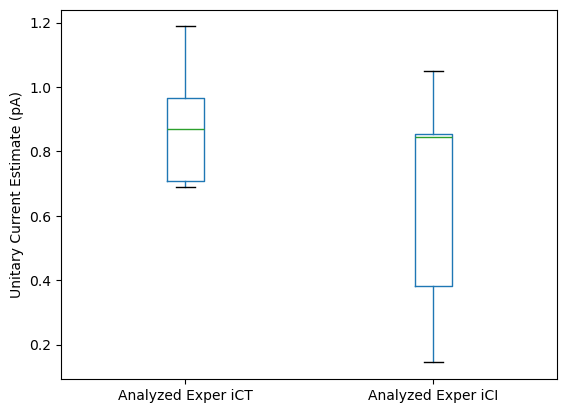

Median iCI = nan


In [7]:
import seaborn as sns

sorted_master_df["Analyzed Exper iCT"] = control_cell_i_list
sorted_master_df["Analyzed Exper iCI"] = IEM_cell_i_list
print(sorted_master_df)
boxplot = sorted_master_df.boxplot(column=['Analyzed Exper iCT','Analyzed Exper iCI'])
plt.grid(False)
# boxplot = sorted_master_df.boxplot(column=['Analyzed Exper iCI'])
plt.ylabel("Unitary Current Estimate (pA)")
plt.show()


sorted_master_df['IEM DOSE'] = pd.Categorical(sorted_master_df['IEM DOSE'])
# sns.stripplot(data=sorted_master_df, x='IEM DOSE', y='Analyzed Exper iCI', color='black', alpha=0.5)

print(f"Median iCI = {np.median(sorted_master_df["Analyzed Exper iCI"])}")



posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


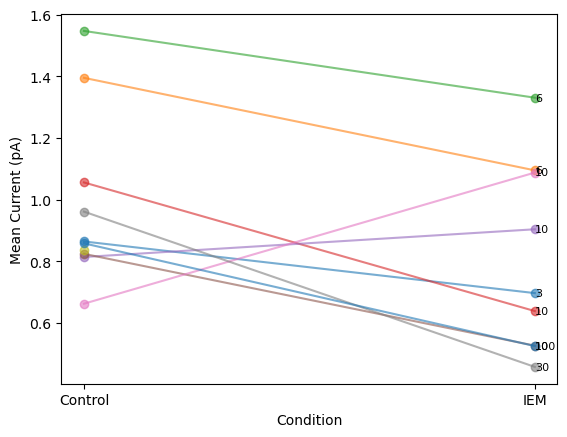

In [28]:
x = ["Analyzed Exper iCT", "Analyzed Exper iCI"]
sub_df = sorted_master_df[x]
plt.figure()
for i, row in sub_df.iterrows():
    plt.plot(["Control","IEM"],row.values,marker='o',alpha=.6)
    plt.text(
        "IEM",
        row["Analyzed Exper iCI"],
        str(sorted_master_df["IEM DOSE"][i]),
        fontsize=8,
        ha='left',
        va='center'
    )

plt.xlabel("Condition")
plt.ylabel("Mean Current (pA)")
plt.show()


## Figures for ARO ##

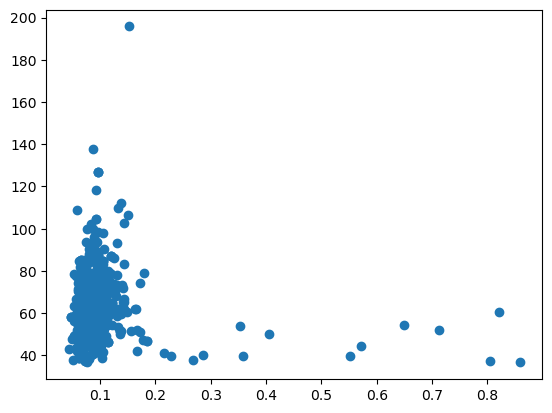

(0.0, 800.0)

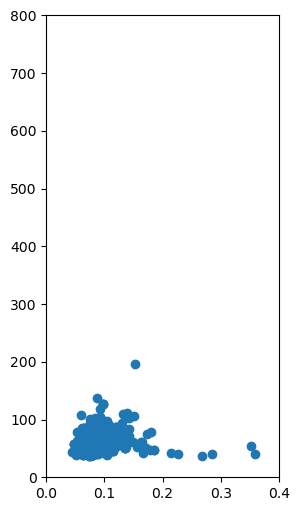

In [105]:
#Comparing CDF of rise times and amplitudes between control and simulations



IEM_cell = pd.read_excel(IEM_path ,sheet_name='JG18D05A_IEM100')
IEM_cell_clean = IEM_cell.sub(IEM_cell.iloc[:15].mean())

    
exp_rise_times = np.array(rise_times_histogram_creator(IEM_cell, "/", sampling_rate=0.02, plt_show=False))
exp_amps = np.array(amplitude_histogram_creator(clean_IEM_cell,"/",plt_show = False))


plt.scatter(exp_rise_times,exp_amps)
plt.show()



exp_rise_times_clean = []
exp_amps_clean = []

for idx, rt in enumerate(exp_rise_times):
    if rt < 0.4:
        exp_rise_times_clean.append(rt)
        exp_amps_clean.append(exp_amps[idx])
plt.figure(figsize=(3,6))

plt.scatter(exp_rise_times_clean, exp_amps_clean)
plt.xlim(0,.4)
plt.ylim(0,800)


Glu is normal


Processing traces: 100%|█████████████████████████████████████████████████████████████| 500/500 [00:29<00:00, 16.72it/s]


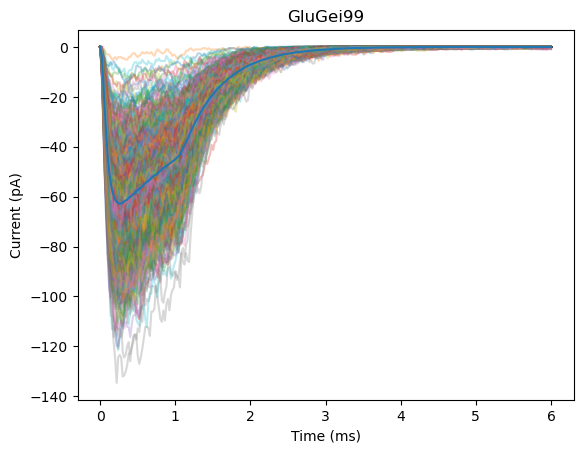

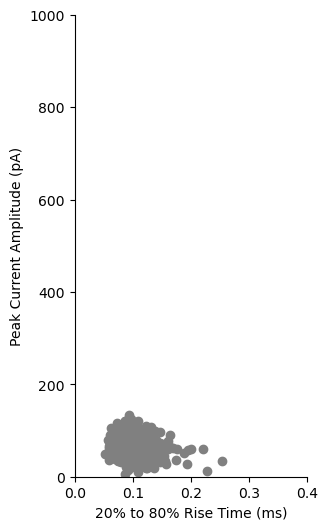

<Figure size 640x480 with 0 Axes>

In [110]:
#Optimizing the simulation to mimic the IEM cells
experimental_sampling_rate = .02 ###300 samples, 6 seconds, 6/300 = .02 seconds/sample
params = {
    'fixed_glu_conc':6, #mM
    'glu_distribution':'normal' ,#fixed or normal or uniform random
    'glu_mean': 6,
    'glu_std':1,
    'glu_upper_lim':100,
    'channel_distribution':'normal', #fixed or normal
    'transient_type': 'Veruki', #Veruki or JGT
    'RC_multiplier': 3,
    'channel_mean': 300,
    'channel_std':100,
    'fixed_n_value':None,
    'channels_lower_lim': 0,
    'ci_ratio':None,
    'ci_current': -.51 ,#in picoamps
    'cp_current': -1.53


}

num_traces = 500



# Rate Constants in s-1 unless indicated as m-1s-1
kC0C1 = 17.1e6 #m-1s-1
kC1C0 = 157
kC1C2 = 3.24e6 #m-1s-1
kC2C1 = 3.76e3
kC2O = 14.9e3
kOC2 = 4e3 * params['RC_multiplier']
kC1C3 = 1.53e3
kC3C1 = 408
kC2C4 = 502
kC4C2 = .377
kOC5 = 121 * params['RC_multiplier']
kC5O = 191
kC3C4 = .611e6 #m-1s-1
kC4C3 = 2
kC4C5 = 1.59e3
kC5C4 = 899e3


#State definitions
STATE_MAP = {'C0':0, 'C1':1, 'C2':2, 'C3':3, 'C4':4, 'C5':5, 'O':6}
STATE_NAMES = {v:k for k,v in STATE_MAP.items()}


#########
g = 8.5e-12 #conductance
V_hold = -60e-3 #holding potential
V_rev = 0  #reversal potential

#########


##Agonist Parameters
agonist_conc = 1e-3 * params['fixed_glu_conc'] #Just a starting parameter
pulse_start = 0 #Start at beginning
pulse_end = 0.001 #end at 1ms


##Time Parameters
t_max = 0.006 # 10ms
n_samples = 300 #Time interval defined as 10microseconds, across 10ms, means 10,000microseconds and 1000 samples
t_eval = np.linspace(0,t_max,n_samples)
time_ms = t_eval * 1e3
RATES = {
        0: lambda t: np.array([kC0C1 * agonist_conc_t(t)]),
        1: lambda t: np.array([kC1C0, kC1C3, kC1C2 * agonist_conc_t(t)]),
        2: lambda t: np.array([kC2C1, kC2C4, kC2O]),
        3: lambda t: np.array([kC3C1, kC3C4 * agonist_conc_t(t)]),
        4: lambda t: np.array([kC4C2, kC4C5, kC4C3]),
        5: lambda t: np.array([kC5O, kC5C4]),
        6: lambda t: np.array([kOC2, kOC5])
    }
DESTS = {
        0: np.array([1]),           # C0 → C1
        1: np.array([0, 3, 2]),     # C1 → C0, C3, C2
        2: np.array([1, 4, 6]),     # C2 → C1, C4, O
        3: np.array([1, 4]),        # C3 → C1, C4
        4: np.array([2, 5, 3]),     # C4 → C2, C5, C3
        5: np.array([6, 4]),        # C5 → O, C4
        6: np.array([2, 5])         # O → C2, C5
    }

#For the sake of this experiment, we will tweak the simulation code to have the same setup
###############Simulate EPSCs###########################
# def run_simulation(params):
    
    


all_traces = []
np.random.seed(189)
if params['channel_distribution'] == 'normal':
    mean = params['channel_mean']
    std = params['channel_std']
    lower_lim = params['channels_lower_lim']
    N_array = np.random.normal(mean, std, num_traces)
    N_array = np.clip(N_array, lower_lim, 4000)



elif params['channel_distribution'] == 'fixed':
    fixed_N = params['fixed_n_value']
    N_array =  np.full(num_traces, fixed_N)


if params['glu_distribution'] == 'normal':
    mean = params['glu_mean']
    std = params['glu_std']
    glu_array = np.random.normal(mean,std,num_traces)
    print("Glu is normal")

elif params['glu_distribution'] == 'fixed':
    fixed_glu = params['fixed_glu_conc']
    glu_array = np.full(num_traces,fixed_glu)


elif params['glu_distribution'] == 'uniform':
    glu_array = np.random.uniform(.002, .05, num_traces)
    print(glu_array)




for trace_id in tqdm(range(num_traces), desc="Processing traces"):
    open_counts = np.zeros_like(t_eval, dtype=int)

    # simulate N independent channels and sum their openings
    N = int(N_array[trace_id])
    if glu_array[trace_id] > params['glu_upper_lim']: 
        glu_array[trace_id] = params['glu_upper_lim']
    agonist_conc = glu_array[trace_id] * 1e-3
    for n in range(N):
        times_n, states_n = simulate_one_channel(t_max,agonist_conc)
        open_counts += events_to_sampled_open(times_n, states_n, t_eval)

    

    I_pA = open_counts * params['ci_current']#g * (V_hold - V_rev)  # Amps


    all_traces.append(I_pA)

# Convert to DataFrame: each column is one trace, rows are timepoints
df = pd.DataFrame(np.array(all_traces).T, index=t_eval)

plt.xlabel("Time (ms)")
plt.ylabel("Current (pA)")
for col in df.columns:
    plt.plot(df.index*1e3,df[col],alpha=.3)
template = np.mean(df,axis=1)
plt.plot(df.index*1e3,template)
plt.title("GluGei99")
plt.show()
df.columns = [f"trace_{i+1}" for i in range(num_traces)]


df = df*-1
type = params['transient_type'][0:3]
mult = str(params['RC_multiplier'])
dist = params['channel_distribution'][0]
glu_dist = params['glu_distribution'][0]
# df.to_excel(f"C:/Users/j.mona/Documents/GitHub/Python-EPSC-NSFA-Pipeline/experimental-scripts//CI_CP_Redo/normalglu_normaln_ci{ci_multiple}_test.xlsx")
# return  df

# df = run_simulation(params)

   
# plt.xlabel("Time (ms)")
# plt.ylabel("Current (pA)")
df_pos = df.to_numpy() 
df_pos = pd.DataFrame(df_pos)

rise_times = np.array(rise_times_histogram_creator(df_pos, "/", sampling_rate=0.02, plt_show=False))
amps = np.array(amplitude_histogram_creator(df_pos,"/",plt_show = False))
plt.figure(figsize=(3,6))
plt.scatter(rise_times,amps,color='grey')
plt.xlim(0,.4)

plt.ylim(0,1000)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("20% to 80% Rise Time (ms)")
plt.ylabel("Peak Current Amplitude (pA)")
plt.show()
x_min, x_max = 0, 1     #  rise time range
y_min, y_max = 0, 400  #  count or density


# plt.xlim(x_min, x_max)
# plt.ylim(y_min, y_max)


plt.tight_layout()
plt.show()


# for col in df.columns:
#     plt.plot((df.index*1e3),df[col],alpha=.3)
# plt.xlabel("Time (ms)")
# plt.ylabel(f"Amplitude (pA)") 
# plt.title("Simulation EPSCs")
# plt.show()


KS statistic: 0.22489126559714795
P statistic: 3.2276443644100677e-12
Length of exp: 553


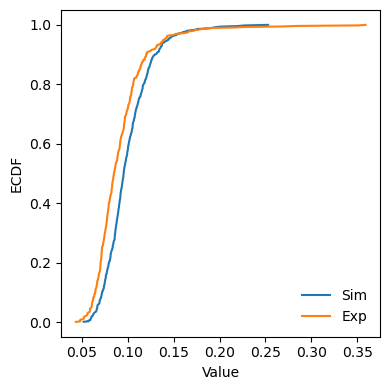

Max sim: 0.2528444444444445
Max exp: 0.3589563995693221
KS statistic: 0.19914285714285715


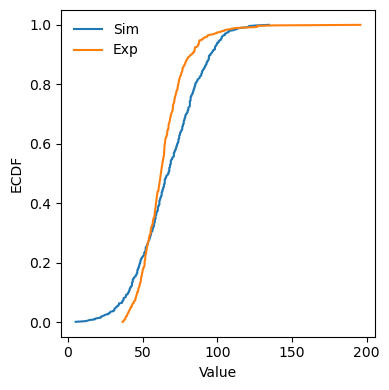

195.8151244


In [111]:
sim_rise_times = np.array(rise_times_histogram_creator(df_pos, "/", sampling_rate=0.02, plt_show=False))
sim_amps = np.array(amplitude_histogram_creator(df_pos,"/",plt_show = False))

D, p= ks_2samp(sim_rise_times, exp_rise_times)
print("KS statistic:", D)
print("P statistic:", p)

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y
print(f"Length of exp: {len(exp_rise_times_clean)}")
x1, y1 = ecdf(sim_rise_times)
x2, y2 = ecdf(exp_rise_times_clean)

plt.figure(figsize=(4,4))
plt.plot(x1, y1, label="Sim")
plt.plot(x2, y2, label="Exp")
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Max sim:", np.max(sim_rise_times))
print("Max exp:", np.max(exp_rise_times_clean))



D, _ = ks_2samp(sim_amps, exp_amps_clean)
print("KS statistic:", D)



x1, y1 = ecdf(sim_amps)
x2, y2 = ecdf(exp_amps_clean)

plt.figure(figsize=(4,4))
plt.plot(x1, y1, label="Sim")
plt.plot(x2, y2, label="Exp")
plt.xlabel("Value")
plt.ylabel("ECDF")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(np.max(exp_amps_clean))

In [126]:
df_pos.columns = range(len(df_pos.columns))

print(df_pos)

       0      1      2      3      4      5      6      7      8      9    \
0     1.02   2.55   5.61   3.57   5.10   2.04   3.57   3.06   0.00   1.02   
1     7.14  10.71  16.32  15.81  19.38  12.24  16.83  10.20   1.02   4.59   
2    13.77  18.87  32.13  27.54  41.82  22.95  33.66  24.48   4.08  12.24   
3    18.36  27.03  41.82  42.84  62.22  39.27  50.49  33.66   7.65  18.36   
4    20.40  28.05  51.00  53.04  77.01  44.88  65.28  42.33  10.20  25.50   
..     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
294   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
295   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
296   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
297   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
298   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   

     ...    490    491    492    493    494    495    496    497    498    

In [129]:
#Looking at NSFA for simulations
sim_rise_times = pd.Series(rise_times_histogram_creator(df_pos, "/", sampling_rate=0.02, plt_show=False))

bin_width = 0.02
freq_cutoff = 100

bins = np.arange(sim_rise_times.min(),
                 sim_rise_times.max() + bin_width,
                 bin_width)

binned = pd.Series(
    pd.cut(sim_rise_times, bins=bins, include_lowest=True)
)

print(binned)

# Extract bin categories
bin_categories = binned.cat.categories
bin_categories = [cat for cat in bin_categories if cat.right <= 0.4]
print(f"Control bin_categories {bin_categories}")
bin_counts = binned.value_counts().sort_index()  # sort_index ensures bins are in order
for i, category in enumerate(bin_categories, start=1):
    # Get columns that fall into this bin
    cols_in_bin = sim_rise_times.index[binned == category]
    if len(cols_in_bin) > freq_cutoff:
        subset = df_pos.loc[:, cols_in_bin]
        
        #Run NSFA on the subset and add the linear i result to the mean's list
        params = {
                "direct_df_input": True,
                "alignment": ["peak"],
                "analysis_start_point": ["peak_start"],
                "scaling": ["minimize_error"],
                "output": ["linear", "parabolic"],
                "file_name": None,
                "folder_name": 'Downloads/',
                "recording_duration":6,
                "theoretical_current":.51,
                "theoretical_mean": params["channels_mean"],
                "EPSCs": subset,
                "sheet_names":['Simulation']
        
            }
        
        matrix = matrix_generator(params,first_sheet=False,debug=False,save_figs=False)
        matrix_df = pd.DataFrame(matrix)
        lin_i = matrix_df["linear_i"][0]
        simulation_bins_list.append(lin_i)
        
        print(matrix_df)
        print(f"Simulation bins: {simulation_bins_list}")


    
print(control_cell_i_list)

               

            
    



0      (0.0721, 0.0921]
1       (0.0921, 0.112]
2       (0.0921, 0.112]
3        (0.132, 0.152]
4      (0.0721, 0.0921]
             ...       
495     (0.0921, 0.112]
496     (0.0921, 0.112]
497     (0.0921, 0.112]
498    (0.0721, 0.0921]
499     (0.0921, 0.112]
Length: 500, dtype: category
Categories (11, interval[float64, right]): [(0.0511, 0.0721] < (0.0721, 0.0921] < (0.0921, 0.112] < (0.112, 0.132] ... (0.192, 0.212] < (0.212, 0.232] < (0.232, 0.252] < (0.252, 0.272]]
Control bin_categories [Interval(0.0511, 0.0721, closed='right'), Interval(0.0721, 0.0921, closed='right'), Interval(0.0921, 0.112, closed='right'), Interval(0.112, 0.132, closed='right'), Interval(0.132, 0.152, closed='right'), Interval(0.152, 0.172, closed='right'), Interval(0.172, 0.192, closed='right'), Interval(0.192, 0.212, closed='right'), Interval(0.212, 0.232, closed='right'), Interval(0.232, 0.252, closed='right'), Interval(0.252, 0.272, closed='right')]


Processing Excel files: 100%|██████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.54file/s]

Shape of EPSCs: (299, 164)
Aligning by peaks. EPSC Peak Index = 15
False
0
False
float64
121.38 0.0
(299, 164)
Template shape: (299,)
Row indices with NaN: []
Column indices with NaN: []
Peak Index 15
Pool Indices: [0, 163]
Endpoint: 199
The start index of the analysis is:  peak_start
The peak index of the analysis is 15
The indices of the decay segment (w.rt starting point) are:  [0, 1, 2, 3, 4, 5, 8, 11, 12, 16, 18, 20, 23, 26, 29, 31, 33, 36, 38, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 57, 58, 60, 61, 64, 66, 68, 70, 73, 76, 79, 83, 87, 93, 100, 110, 126, 183]
Analysis Type 3 Chosen
{'cell_name': 'Simulation', 'alignment': 'peak', 'analysis_start_point': 'peak_start', 'scaling': 'minimize_error', 'linear_i': 0.6584462375794238, 'parabolic_i': 1.8878228270409325, 'num_channels': 40.21712475884191, 'template_max': 70.14054878048779}
    cell_name alignment analysis_start_point         scaling  linear_i  \
0  Simulation      peak           peak_start  minimize_error  0.

KeyError: 'channel_mean'

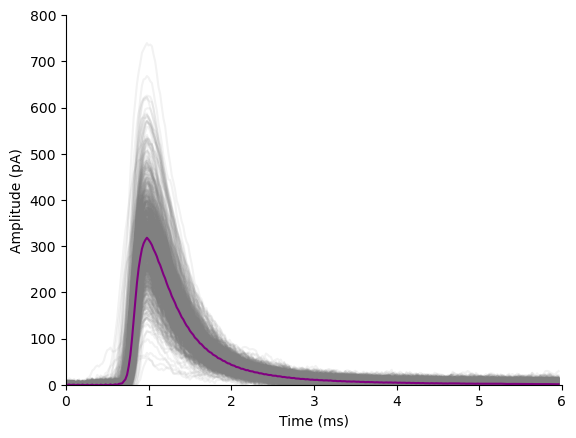

In [33]:
##Comparing rise times!

# n_cells = 3

# fig2, axes2 = plt.subplots(nrows=n_cells,ncols=2,figsize=(8,2.5*n_cells))
# fig3,axes3 = plt.subplots(nrows=n_cells,ncols=2,figsize=(16,5*n_cells))

saturated_cells = ["JG18D05A","JG21O23A","JG18320A"]
colors = ["purple", "blue", "green"]
##Example EPSC## 
EPSC_control_example = pd.read_excel(control_path ,sheet_name="JG18D05A")
for col in EPSC_control_example.columns:
        baseline  = np.mean(EPSC_control_example[col][0:15])    
        clean_col = EPSC_control_example[col] - baseline
        plt.plot((EPSC_control_example.index*.02),clean_col,alpha=.1,color="gray")

plt.plot((EPSC_control_example.index*.02),EPSC_control_example.mean(axis=1),alpha=1,color="purple")
plt.xlim(0,6)
plt.ylim(0,800)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (pA)")
plt.show()




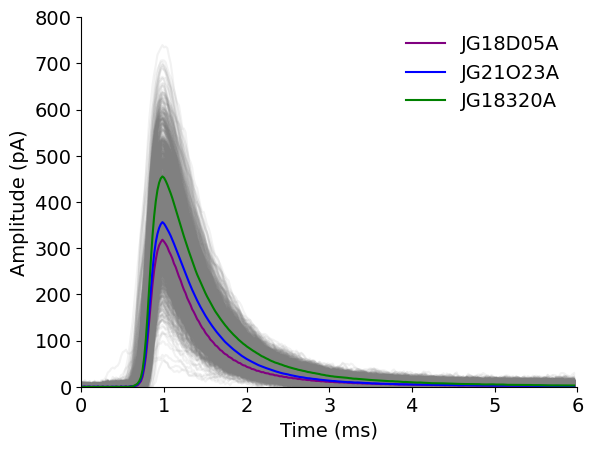

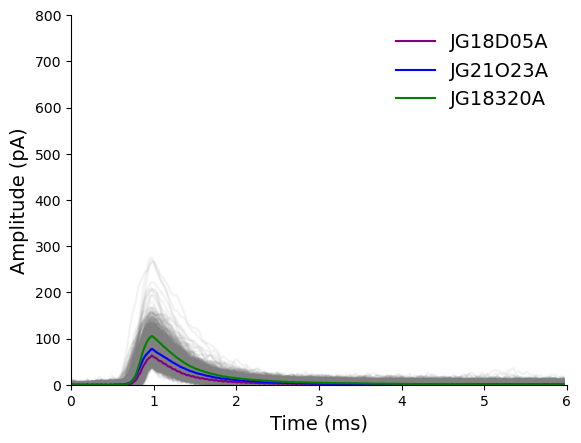

In [34]:
colors = ["purple", "blue", "green"]

for i, cell in enumerate(saturated_cells):

    control_EPSC = pd.read_excel(control_path ,sheet_name=cell)
    for col in control_EPSC.columns:
            baseline  = np.mean(control_EPSC[col][0:15])    
            clean_col = control_EPSC[col] - baseline
            plt.plot((control_EPSC.index*.02),clean_col,alpha=.1,color="gray")

for i, cell in enumerate(saturated_cells):
    control_EPSC = pd.read_excel(control_path ,sheet_name=cell)
    plt.plot((control_EPSC.index*.02),control_EPSC.mean(axis=1),alpha=1,color=colors[i],label=cell)

plt.xlim(0,6)
plt.legend(
    loc='upper right',   # Legend position
    fontsize=14,         # Font size
    frameon=False)
plt.ylim(0,800)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Time (ms)",fontsize=14)
plt.ylabel("Amplitude (pA)",fontsize=14)
plt.show()




colors = ["purple", "blue", "green"]

for i, cell in enumerate(saturated_cells):
    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
    for col in IEM_df.columns:
            baseline  = np.mean(IEM_df[col][0:15])    
            clean_col = IEM_df[col] - baseline
            plt.plot((IEM_df.index*.02),clean_col,alpha=.1,color="gray")

for i, cell in enumerate(saturated_cells):
    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
    plt.plot((IEM_df.index*.02),IEM_df.mean(axis=1),alpha=1,color=colors[i],label=cell)

plt.xlim(0,6)
plt.legend(
    loc='upper right',   # Legend position
    fontsize=14,         # Font size
    frameon=False)
plt.ylim(0,800)
ax.tick_params(axis='both', labelsize=14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Time (ms)",fontsize=14)
plt.ylabel("Amplitude (pA)",fontsize=14)
plt.show()

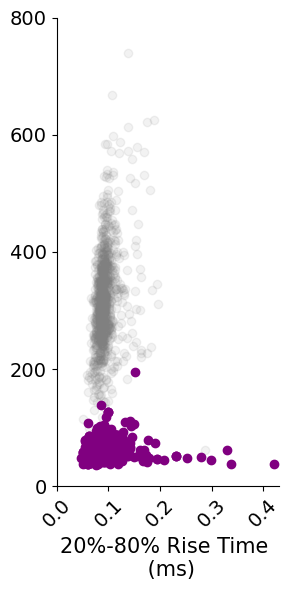

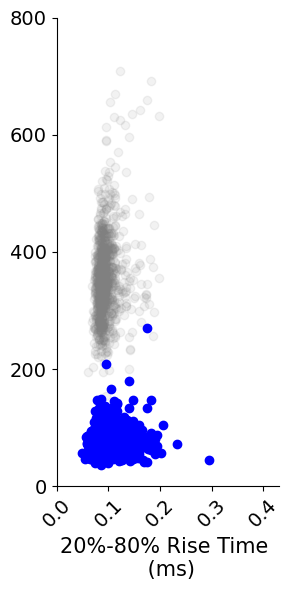

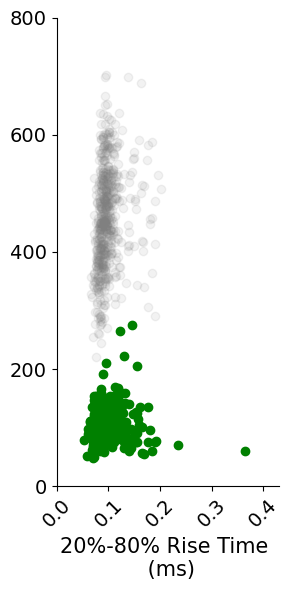

In [48]:
colors = ["purple", "blue", "green"]



for i, cell in enumerate(saturated_cells):
    plt.figure(figsize=(3,6))
    control_EPSC = pd.read_excel(control_path ,sheet_name=cell)
    control_EPSC = control_EPSC.sub(control_EPSC.iloc[:20].mean())

    rise_times = np.array(rise_times_histogram_creator(control_EPSC, "/", sampling_rate=0.02, plt_show=False))
    amps = np.array(amplitude_histogram_creator(control_EPSC,"/",plt_show = False))
      
    plt.scatter(rise_times,amps,alpha=.1,color='grey',label=cell)

    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]  
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_EPSC = pd.read_excel(IEM_path,sheet_name=IEM_label)
    IEM_EPSC = IEM_EPSC.sub(IEM_EPSC.iloc[:20].mean())

    rise_times = np.array(rise_times_histogram_creator(IEM_EPSC, "/", sampling_rate=0.02, plt_show=False))
    amps = np.array(amplitude_histogram_creator(IEM_EPSC,"/",plt_show = False))
      
    plt.scatter(rise_times,amps,alpha=1,color=colors[i],label=cell)

    plt.xlim(0,.43)
    plt.ylim(0,800)
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=14)

    ax.set_xticks(np.arange(0, 0.43, 0.1))
    ax.set_yticks(np.arange(0, 801, 200))
    ax.tick_params(axis='x', labelrotation=45)

    ax.set_xlabel("20%-80% Rise Time \n (ms)", fontsize=15)
    # ax.set_ylabel("Peak Current Amplitude (pA)", fontsize=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    


# for i, cell in enumerate(saturated_cells):
#     plt.figure(figsize=(3,6))

#     IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
#     IEM_label = cell + f"_IEM{IEM_DOSE}"
#     IEM_EPSC = pd.read_excel(IEM_path,sheet_name=IEM_label)
#     rise_times = np.array(rise_times_histogram_creator(IEM_EPSC, "/", sampling_rate=0.02, plt_show=False))
#     amps = np.array(amplitude_histogram_creator(IEM_EPSC,"/",plt_show = False))
      
#     plt.scatter(rise_times,amps,alpha=.1,color=colors[i],label=cell)

#     plt.scatter(np.mean(rise_times),np.mean(amps),s=150,color=colors[i],marker=marker)


#     plt.xlim(0,.25)
#     # plt.legend(
#     #     loc='upper right',   # Legend position
#     #     fontsize=10,         # Font size
#     #     frameon=False)
#     plt.ylim(0,800)
#     ax = plt.gca()
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     plt.xlabel("20% to 80% Rise Time (ms)")
#     plt.ylabel("Peak Current Amplitude (pA)")
#     plt.show()
    

# colors = ["purple", "blue", "green"]

# for i, cell in enumerate(saturated_cells):
#     IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
#     IEM_label = cell + f"_IEM{IEM_DOSE}"
#     IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
#     for col in IEM_df.columns:
#             baseline  = np.mean(IEM_df[col][0:15])    
#             clean_col = IEM_df[col] - baseline
#             plt.plot((IEM_df.index*.02),clean_col,alpha=.1,color="gray")

# for i, cell in enumerate(saturated_cells):
#     IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
#     IEM_label = cell + f"_IEM{IEM_DOSE}"
#     IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
#     plt.plot((IEM_df.index*.02),IEM_df.mean(axis=1),alpha=1,color=colors[i],label=cell)

# plt.xlim(0,6)
# plt.legend(
#     loc='upper right',   # Legend position
#     fontsize=10,         # Font size
#     frameon=False)
# plt.ylim(0,1000)
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.xlabel("Time (ms)")
# plt.ylabel("Amplitude (pA)")
# plt.show()

In [ ]:
for i, cell in enumerate(saturated_cells):
    
 
    control_df = pd.read_excel(control_path ,sheet_name=cell)
    for col in control_df.columns:
                baseline = np.mean(control_df[col][0:15])
                control_df[col] = control_df[col] - baseline

    
    IEM_DOSE = sorted_master_df[sorted_master_df["CELL ID"] == cell]["IEM DOSE"].iloc[0]
    
    IEM_label = cell + f"_IEM{IEM_DOSE}"
    IEM_df = pd.read_excel(IEM_path,sheet_name=IEM_label)
    for col in IEM_df.columns:
                baseline = np.mean(IEM_df[col][0:15])
                IEM_df[col] = IEM_df[col] - baseline
    bin_width = .02
    # Compute rise times
    rise_times = np.array(rise_times_histogram_creator(control_df, "/", sampling_rate=0.02, plt_show=False))
    IEM_rise_times = np.array(rise_times_histogram_creator(IEM_df, "/", sampling_rate=0.02, plt_show=False))
    bins = np.arange(rise_times.min(), rise_times.max() + bin_width, bin_width)


    #Compute amplitudes
    amps = np.array(amplitude_histogram_creator(control_df,"/",plt_show = False))
    IEM_amps = np.array(amplitude_histogram_creator(IEM_df,"/",plt_show = False))

    axes2[i,0].scatter(rise_times,amps)
    axes2[i,0].set_ylabel(f"{cell} \n Amplitude (pA)") 
    axes2[i,0].set_xlabel("Rise Times (ms)") 

    axes2[i,0].set_title("Control")

    axes2[i,1].scatter(IEM_rise_times,IEM_amps)
    axes2[i,1].set_title(f"IEM {IEM_DOSE}μM")
    axes2[i,1].set_xlabel("Rise Times (ms)") 


    # Plot raw EPSCs
    for col in control_df.columns:
        baseline  = np.mean(control_df[col][0:15])    
        clean_col = control_df[col] - baseline
        axes3[i,0].plot((control_df.index*.02),clean_col,alpha=.3)
        axes3[i,0].axvline(x=.3)

    axes3[i,0].set_ylabel(f"{cell} \n Amplitude (pA)") 
    axes3[i,0].set_title("Control")
    axes3[i,0].set_xlabel("Time (ms)")



    for col in IEM_df.columns:
        baseline  = np.mean(IEM_df[col][0:15])   
        clean_col = IEM_df[col] - baseline
        axes3[i,1].plot((IEM_df.index),clean_col,alpha=.3) 
        axes3[i,1].axvline(x=15)

    axes3[i,1].set_ylabel("Current (pA)")
    axes3[i,1].set_title(f"IEM {IEM_DOSE}μM")
    axes3[i,1].set_xlabel("Time (ms)")



    







# ############
# x_min, x_max = 0, 1     #  rise time range
# y_min, y_max = 0, 1000  #  amplitude range

# for ax_row in axes2:
#     for ax in ax_row:
#         ax.set_xlim(x_min, x_max)
#         ax.set_ylim(y_min, y_max)
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)


# ##########
# for ax_row in axes3:
#     for ax in ax_row:
#         ax.set_ylim(y_min, y_max)
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

# plt.tight_layout()
# plt.savefig("Experimental_RiseTime_Amp_Plots.png")
# plt.show()




    